### Alejandro Conesa Más, Stefania Bianchi, Alex Garre Vera, Carla Milán García

# Proyecto Final

## 1. Análisis exploratorio (EDA)

En esta fase se realiza un análisis exploratorio crítico (EDA) del dataset COMPAS con el objetivo de comprender la estructura de los datos e identificar posibles patrones de sesgo relacionados con la predicción de reincidencia criminal.


COMPAS se popularizó tras la investigación de **ProPublica "Machine Bias"** (Angwin et al., 2016), donde se reportaron diferencias significativas en las tasas de falsos positivos entre grupos raciales dentro del sistema de predicción de reincidencia. Por ello, este contexto motiva el análisis exploratorio realizado en este EDA, centrado en estudiar si existen diferencias entre grupos raciales en la variable objetivo `two_year_recid`, en las puntuaciones `decile_score` y en métricas descriptivas de error como FPR y FNR.


En primer lugar, se analiza el dataset desde un punto de vista descriptivo, estudiando el número de instancias, los tipos de variables, la presencia de valores faltantes y posibles valores extremos. También se examina la distribución de la variable objetivo (`two_year_recid`) para evaluar el grado de desbalanceo del problema.

El análisis se centra en en la variable sensible `race` debido a su relevancia histórica y social en el debate sobre _fairness_ en sistemas judiciales automatizados. Se estudian las diferencias entre grupos raciales en términos de tasa de reincidencia, puntuaciones de riesgo asignadas por COMPAS (`decile_score` y `score_text`) y distribución de individuos clasificados como “High Risk”. También se analiza el impacto de la variable sensible `sex`.

Además, se realiza un análisis descriptivo de fairness mediante la comparación de métricas como la tasa de falsos positivos (FPR) y falsos negativos (FNR) entre grupos raciales, con el objetivo de detectar posibles disparidades en el comportamiento del sistema COMPAS. Finalmente, se utilizan matrices de correlación y visualizaciones gráficas para identificar relaciones relevantes entre todas las variables.


Investigación: Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). Machine Bias. ProPublica. https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing

### 1.1. Preprocesamiento de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import shap
import matplotlib.gridspec as gridspec


from sklearn.preprocessing import LabelEncoder

os.makedirs("./images", exist_ok=True)

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

df = pd.read_csv(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
)

print("*" * 40)
print(f"Shape: {df.shape}")
print("*" * 40)

print(df.dtypes)
print("*" * 40)

print(df.head())
print("*" * 40)

print()
print(df.info())

****************************************
Shape: (7214, 53)
****************************************
id                           int64
name                        object
first                       object
last                        object
compas_screening_date       object
sex                         object
dob                         object
age                          int64
age_cat                     object
race                        object
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                   object
c_jail_out                  object
c_case_number               object
c_offense_date              object
c_arrest_date               object
c_days_from_compas         float64
c_charge_degree             object
c_charge_desc               object
is_recid                     int64
r_case_number            

### 1.2. Variables y target

Con el objetivo de construir un conjunto de datos interpretable y alineado con el problema de fairness, se selecciona un subconjunto de 10 variables del dataset COMPAS. Las variables escogidas representan características demográficas (`age`, `sex`, `race`), historial criminal (`prior_counts`, `jul_fel_count`, `juv_misd_count`, `juv_other_count`), gravedad del delito actual (`c_charge_degree`) y puntuaciones generadas por COMPAS (`decile_score`, `score_text`). La variable objetivo del dataset es `two_year_recid`.

In [ ]:
features = [
    "age",
    "sex",
    "race",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "decile_score",
    "score_text",
    "two_year_recid"
]

df_compas = df[features].copy()

print(f"Tamaño tras seleccionar variables: {df_compas.shape}")
display(df_compas.head())

Tamaño tras seleccionar variables: (7214, 11)


,age,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,decile_score,score_text,two_year_recid
0,69,Male,Other,0,0,0,0,F,1,Low,0
1,34,Male,African-American,0,0,0,0,F,3,Low,1
2,24,Male,African-American,4,0,0,1,F,4,Low,1
3,23,Male,African-American,1,0,1,0,F,8,High,0
4,43,Male,Other,2,0,0,0,F,1,Low,0


**COMPAS Features**

* **age**: edad de la persona evaluada.
* **sex**: sexo del individuo.
* **race**: grupo racial registrado. Es una variable sensible clave para el análisis de fairness.
* **priors_count**: número de antecedentes penales previos.
* **juv_fel_count**: número de delitos graves cometidos siendo menor.
* **juv_misd_count**: número de delitos menores cometidos siendo menor.
* **juv_other_count**: otros delitos cometidos siendo menor.
* **c_charge_degree**: gravedad del cargo actual. F = felony, M = misdemeanor.
* **decile_score**: puntuación de riesgo COMPAS de 1 a 10.
* **score_text**: categoría de riesgo asignada por COMPAS: Low, Medium o High.
* **two_year_recid**: variable objetivo. 1 = reincide en dos años, 0 = no reincide.


### 1.3. Valores faltantes y duplicados

El Dataset no cuenta con valores faltantes:

In [ ]:
missing = df_compas.isna().sum()

if missing.sum() == 0:
    print("No hay valores faltantes en las variables seleccionadas")
else:
    print("Hay valores faltantes:")
    print(missing[missing > 0])

No hay valores faltantes en las variables seleccionadas


En cambio, se detectan registros duplicados, que no se eliminan automáticamente ya que múltiples individuos pueden compartir exactamente los mismos valores en las variables seleccionadas. Dado que no se dispone de un identificador único anonimizado fiable dentro del subconjunto utilizado, eliminar duplicados podría eliminar observaciones válidas y alterar la distribución real del dataset.

In [ ]:
# Duplicados
duplicates = df_compas.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates}")

Número de filas duplicadas: 1103


In [ ]:
# Resumen estadístico
display(df_compas.describe(include="all"))

,age,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,decile_score,score_text,two_year_recid
count,7214.000000,7214,7214,7214.000000,7214.000000,7214.000000,7214.000000,7214,7214.000000,7214,7214.000000
unique,NaN,2,6,NaN,NaN,NaN,NaN,2,NaN,3,NaN
top,NaN,Male,African-American,NaN,NaN,NaN,NaN,F,NaN,Low,NaN
freq,NaN,5819,3696,NaN,NaN,NaN,NaN,4666,NaN,3897,NaN
mean,34.817993,NaN,NaN,3.472415,0.067230,0.090934,0.109371,NaN,4.509565,NaN,0.450652
std,11.888922,NaN,NaN,4.882538,0.473972,0.485239,0.501586,NaN,2.856396,NaN,0.497593
min,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,0.000000
25%,25.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,NaN,0.000000
50%,31.000000,NaN,NaN,2.000000,0.000000,0.000000,0.000000,NaN,4.000000,NaN,0.000000
75%,42.000000,NaN,NaN,5.000000,0.000000,0.000000,0.000000,NaN,7.000000,NaN,1.000000


### 1.4. Outliers

Aunque se detectan valores extremos en variables como `priors_count`, no se eliminan en esta fase del análisis ya que pueden representar casos reales y relevantes dentro del contexto judicial. Eliminar automáticamente estos registros podría introducir un sesgo adicional y reducir la representatividad del dataset. Los outliers no se tratan en esta fase.

In [ ]:
# Detección outliers por IQR
def outlier_summary_iqr(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]

    return {
        "feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_limit": lower,
        "upper_limit": upper,
        "n_outliers": len(outliers),
        "outlier_percentage": round(len(outliers) / len(df) * 100, 2)
    }

numeric_features = [
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "decile_score"
]

outlier_table = pd.DataFrame([
    outlier_summary_iqr(df_compas, feature)
    for feature in numeric_features
])

display(outlier_table)

,feature,Q1,Q3,IQR,lower_limit,upper_limit,n_outliers,outlier_percentage
0,age,25.0,42.0,17.0,-0.5,67.5,61,0.85
1,priors_count,0.0,5.0,5.0,-7.5,12.5,455,6.31
2,juv_fel_count,0.0,0.0,0.0,0.0,0.0,282,3.91
3,juv_misd_count,0.0,0.0,0.0,0.0,0.0,415,5.75
4,juv_other_count,0.0,0.0,0.0,0.0,0.0,523,7.25
5,decile_score,2.0,7.0,5.0,-5.5,14.5,0,0.00


Los boxplots muestran valores extremos en variables como `priors_count` y las variables de delitos juveniles. Sin embargo, estos valores no se eliminan porque pueden representar casos reales dentro del contexto judicial. Eliminarlos automáticamente puede reducir la representatividad del dataset e introducir sesgo adicional.

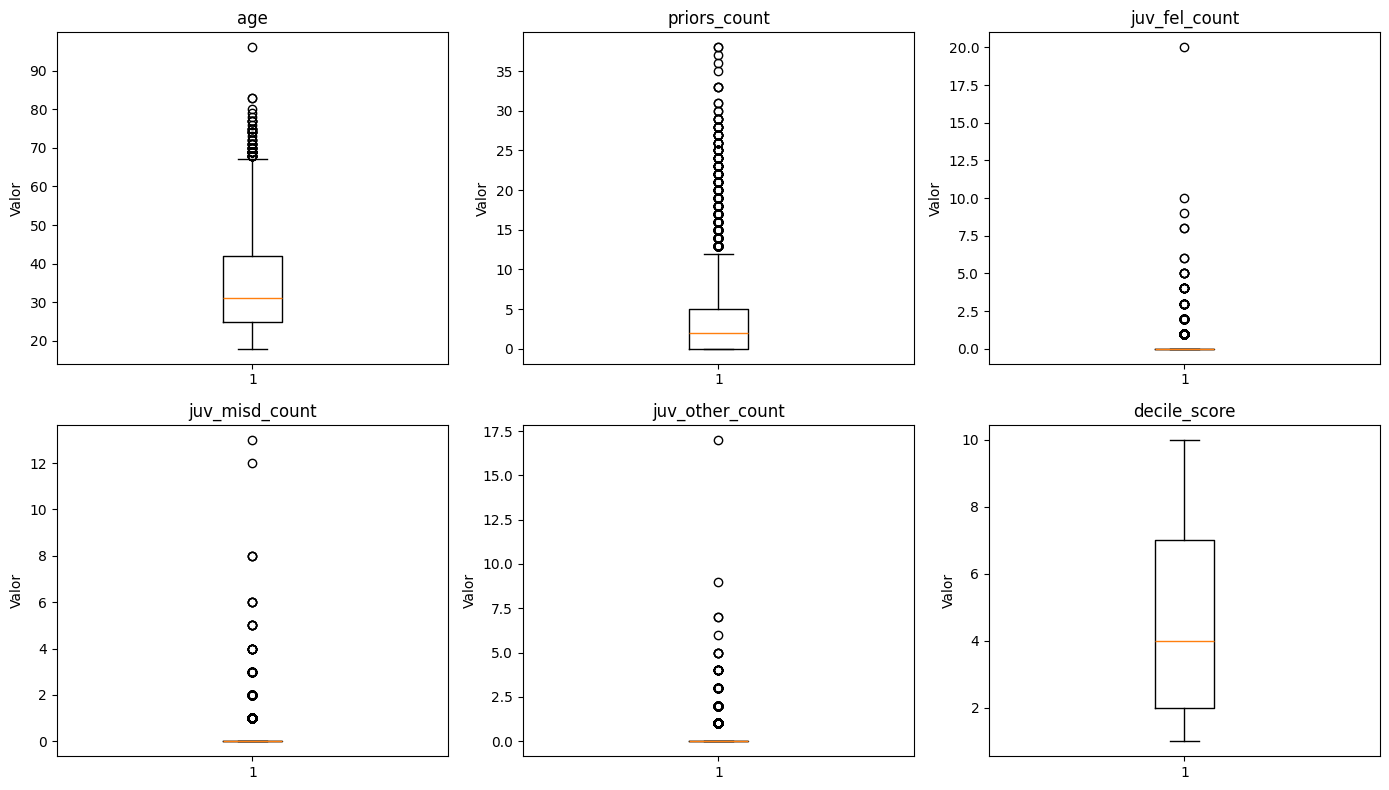

In [ ]:
# Boxplot: valores extremos
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    axes[idx].boxplot(df_compas[feature])
    axes[idx].set_title(feature)
    axes[idx].set_ylabel("Valor")

plt.tight_layout()
plt.savefig("./images/02_boxplots_outliers.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 1.5. Codificación provisional de variables categóricas

Las variables categóricas han sido codificadas numéricamente sólo con fines exploratorios para poder calcular la matriz de correlación. Esta representación no implica una relación ordinal real entre categorías, por lo que no son representativas respecto a su variable original.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_corr = df_compas.copy()

for col in ["sex", "race", "c_charge_degree", "score_text"]:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr_matrix = df_corr.corr(numeric_only=True)

In [ ]:
print(df_compas.describe(include="all"))

                age   sex              race  priors_count  juv_fel_count  \
count   7214.000000  7214              7214   7214.000000    7214.000000   
unique          NaN     2                 6           NaN            NaN   
top             NaN  Male  African-American           NaN            NaN   
freq            NaN  5819              3696           NaN            NaN   
mean      34.817993   NaN               NaN      3.472415       0.067230   
std       11.888922   NaN               NaN      4.882538       0.473972   
min       18.000000   NaN               NaN      0.000000       0.000000   
25%       25.000000   NaN               NaN      0.000000       0.000000   
50%       31.000000   NaN               NaN      2.000000       0.000000   
75%       42.000000   NaN               NaN      5.000000       0.000000   
max       96.000000   NaN               NaN     38.000000      20.000000   

        juv_misd_count  juv_other_count c_charge_degree  decile_score  \
count      721

### 1.6. Distribución de la variable objetivo

La variable objetivo `two_year_recid` presenta un desbalance moderado. La clase mayoritaria corresponde a individuos que no reinciden, aunque la proporción de reincidentes es suficientemente alta para que el problema no sea extremadamente desbalanceado. Por tanto, además de _accuracy_, será conveniente utilizar métricas como _F1-score_, _FPR_, _FNR_ y métricas de _fairness_.

,count,percentage
two_year_recid,,
0,3963,54.93
1,3251,45.07


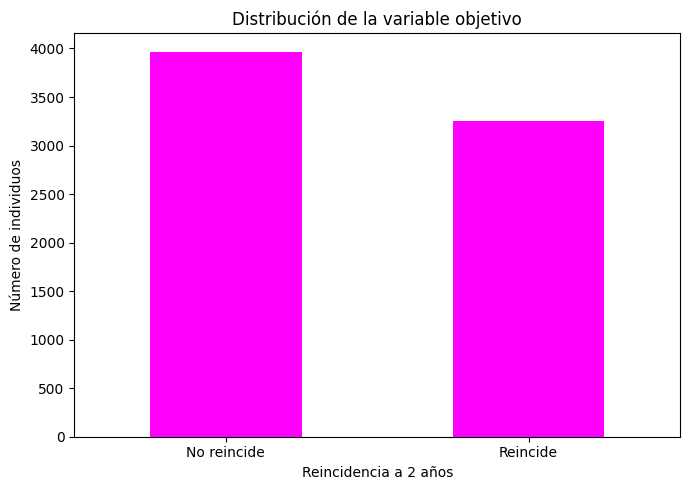

In [ ]:
# Distribución de la variable objetivo
target_counts = df_compas["two_year_recid"].value_counts().sort_index()
target_pct = df_compas["two_year_recid"].value_counts(normalize=True).sort_index() * 100

target_table = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})

display(target_table)

fig, ax = plt.subplots(figsize=(7, 5))

target_counts.plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Reincidencia a 2 años")
ax.set_ylabel("Número de individuos")
ax.set_xticklabels(["No reincide", "Reincide"], rotation=0)

plt.tight_layout()
plt.savefig("./images/01_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 1.7. Visualizaciones

#### 1.7.1. Distribución racial

El dataset no está distribuido de forma uniforme entre grupos raciales. Los grupos _African-American_ y _Caucasian_ concentran la mayor parte de las muestras, mientras que otros grupos como _Asian_ o _Native American_ tienen muy poca representación. Esta diferencia es relevante porque afecta a la estabilidad de las métricas por grupo.

                  count  percentage
race                               
African-American   3696       51.23
Caucasian          2454       34.02
Hispanic            637        8.83
Other               377        5.23
Asian                32        0.44
Native American      18        0.25


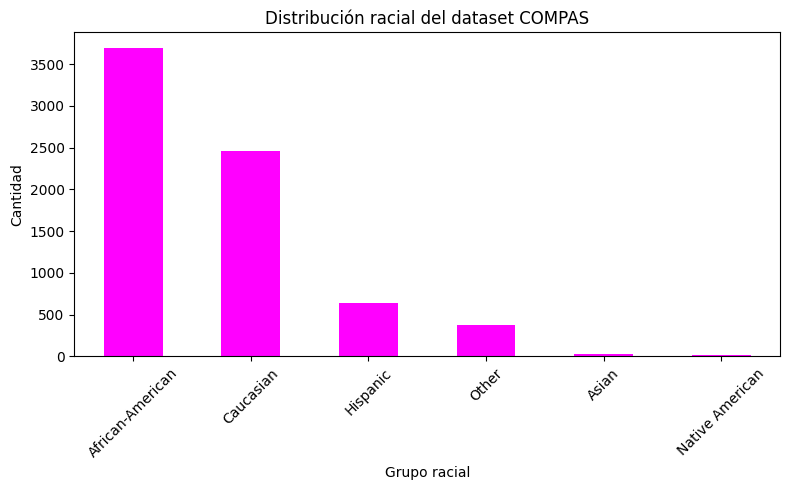

In [ ]:
# Plot Distribución racial
race_counts = df_compas["race"].value_counts()
race_pct = df_compas["race"].value_counts(normalize=True) * 100

race_table = pd.DataFrame({
    "count": race_counts,
    "percentage": race_pct.round(2)
})

print(race_table)

fig, ax = plt.subplots(figsize=(8, 5))

race_counts.plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Distribución racial del dataset COMPAS")
ax.set_xlabel("Grupo racial")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./images/compas_race_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Existen grupos que cuentan con muy pocas muestras, como _Asian_ y _Native American_:

In [ ]:
small_groups = race_table[race_table["count"] < 100]
display(small_groups)

,count,percentage
race,,
Asian,32,0.44
Native American,18,0.25


#### 1.7.2. Tasa de reincidencia por grupo racial

Se observan diferencias en la tasa de reincidencia entre grupos raciales. El grupo _African-American_ presenta una tasa de reincidencia superior a la del grupo _Caucasian_. Esta diferencia no demuestra por sí sola discriminación algorítmica, pero sí indica que la variable sensible `race` está relacionada con la variable objetivo.

                  count      mean  recidivism_rate_%
race                                                
Native American      18  0.555556              55.56
African-American   3696  0.514340              51.43
Caucasian          2454  0.393643              39.36
Hispanic            637  0.364207              36.42
Other               377  0.352785              35.28
Asian                32  0.281250              28.12


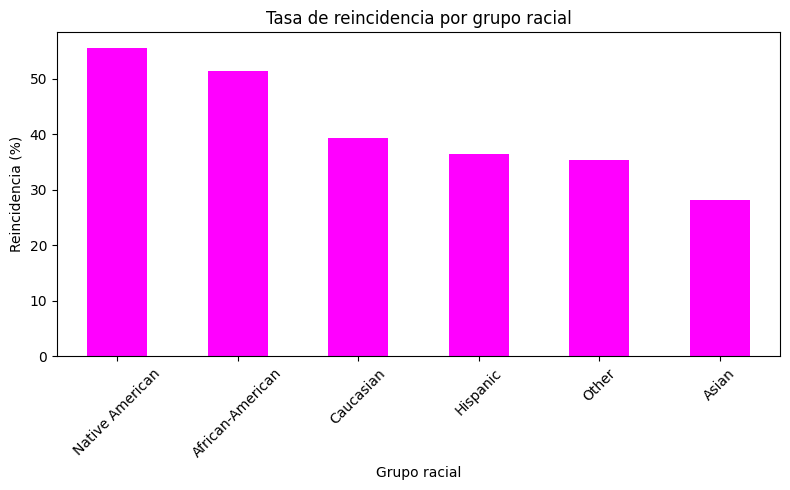

In [ ]:
# Plot. Tasa de reincidencia por grupo racial
recid_by_race = (
    df_compas.groupby("race")["two_year_recid"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

recid_by_race["recidivism_rate_%"] = (recid_by_race["mean"] * 100).round(2)

print(recid_by_race)

fig, ax = plt.subplots(figsize=(8, 5))

recid_by_race["recidivism_rate_%"].plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Tasa de reincidencia por grupo racial")
ax.set_xlabel("Grupo racial")
ax.set_ylabel("Reincidencia (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./images/compas_recidivism_by_race.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### 1.7.3. Heatmap de proporción de reincidencia por grupo racial

El mapa de calor confirma visualmente que la proporción de reincidencia varía entre grupos raciales. Los grupos con pocas muestras deben interpretarse con cautela, pero la diferencia entre _African-American_ y _Caucasian_, al ser grupos mayoritarios, resulta especialmente importante para el análisis de fairness.

two_year_recid        0      1
race                          
African-American  0.486  0.514
Asian             0.719  0.281
Caucasian         0.606  0.394
Hispanic          0.636  0.364
Native American   0.444  0.556
Other             0.647  0.353


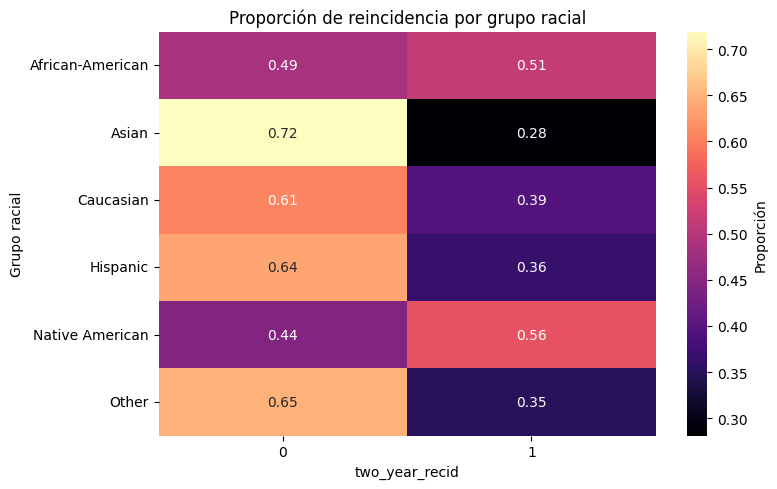

In [ ]:
race_recid_matrix = pd.crosstab(
    df_compas["race"],
    df_compas["two_year_recid"],
    normalize="index"
)

print(race_recid_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    race_recid_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    ax=ax,
    cbar_kws={"label": "Proporción"}
)

ax.set_title("Proporción de reincidencia por grupo racial")
ax.set_xlabel("two_year_recid")
ax.set_ylabel("Grupo racial")

plt.tight_layout()
plt.savefig("./images/compas_heatmap_race_recidivism.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### 1.7.4. Puntuación media COMPAS por grupo racial

La puntuación media `decile_score` no es homogénea entre grupos raciales. El grupo _African-American_ obtiene una puntuación media superior a la del grupo _Caucasian_, lo que sugiere que COMPAS asigna niveles de riesgo distintos según el grupo racial. Esto justifica analizar si dichas diferencias responden únicamente a variables predictivas legítimas o si reflejan sesgos estructurales.

                  count  mean   std
race                               
Native American      18  6.17  2.98
African-American   3696  5.37  2.83
Caucasian          2454  3.74  2.60
Hispanic            637  3.46  2.60
Other               377  2.95  2.35
Asian                32  2.94  2.60


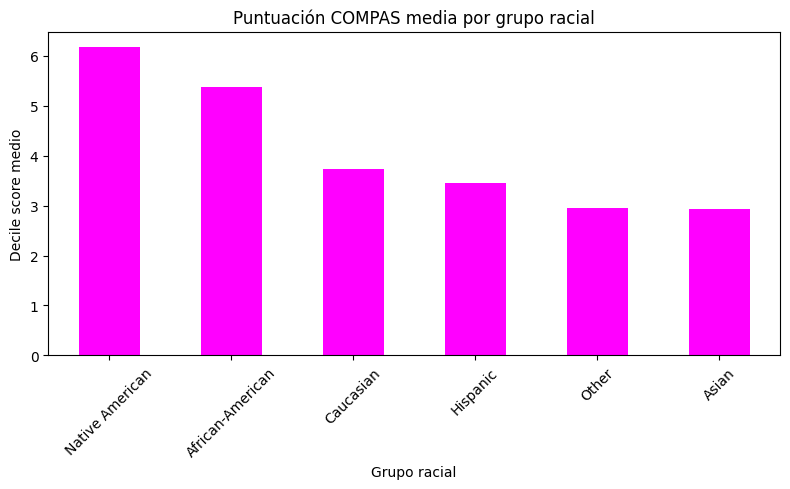

In [ ]:
# COMPAS score medio por raza
score_by_race = (
    df_compas.groupby("race")["decile_score"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)

score_by_race["mean"] = score_by_race["mean"].round(2)
score_by_race["std"] = score_by_race["std"].round(2)

print(score_by_race)

fig, ax = plt.subplots(figsize=(8, 5))

score_by_race["mean"].plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Puntuación COMPAS media por grupo racial")
ax.set_xlabel("Grupo racial")
ax.set_ylabel("Decile score medio")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./images/compas_score_by_race.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### 1.7.5. Porcentaje de alto riesgo por raza

La proporción de individuos clasificados como riesgo alto es mayor en determinados grupos raciales, especialmente en _African-American_. Dado que una clasificación de alto riesgo puede influir en decisiones judiciales, esta diferencia tiene implicaciones éticas importantes y motiva el uso posterior de métricas de equidad.

race
Native American     33.33
African-American    27.73
Caucasian           11.25
Hispanic            10.52
Asian                9.38
Other                6.90
Name: score_text, dtype: float64


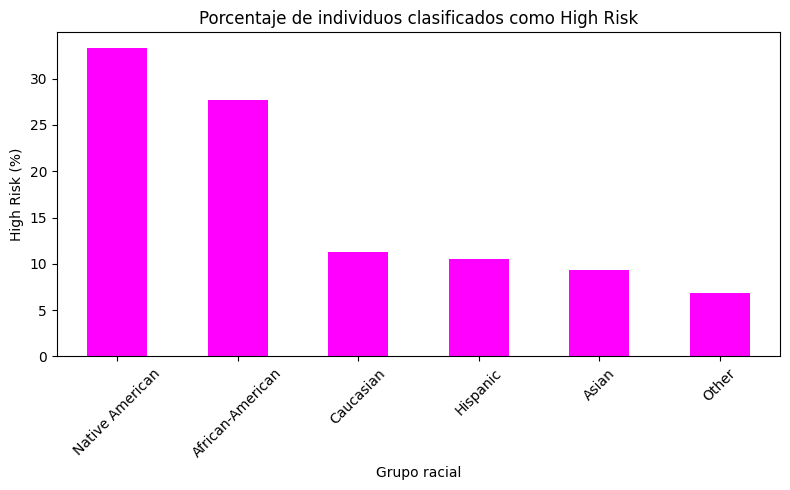

In [ ]:
# Porcentaje de alto riesgo por raza
high_risk_by_race = (
    df_compas.groupby("race")["score_text"]
    .apply(lambda x: np.mean(x == "High") * 100)
    .sort_values(ascending=False)
    .round(2)
)

print(high_risk_by_race)

fig, ax = plt.subplots(figsize=(8, 5))

high_risk_by_race.plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Porcentaje de individuos clasificados como High Risk")
ax.set_xlabel("Grupo racial")
ax.set_ylabel("High Risk (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./images/compas_high_risk_by_race.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### 1.7.6. Correlación con la variable objetivo `two_year_recid`

In [ ]:
target_corr = (
    corr_matrix["two_year_recid"]
    .sort_values(ascending=False)
    .drop("two_year_recid")
)

print(target_corr)

decile_score       0.350703
priors_count       0.275117
juv_misd_count     0.109310
juv_other_count    0.108004
juv_fel_count      0.092546
sex                0.092169
score_text        -0.081502
c_charge_degree   -0.104488
race              -0.123109
age               -0.190323
Name: two_year_recid, dtype: float64


In [ ]:
# Comparación african-american vs caucasian
df_ac = df_compas[
    df_compas["race"].isin(["African-American", "Caucasian"])
].copy()

comparison = (
    df_ac.groupby("race")
    .agg(
        n=("two_year_recid", "count"),
        recidivism_rate=("two_year_recid", "mean"),
        avg_priors=("priors_count", "mean"),
        avg_compas_score=("decile_score", "mean"),
        high_risk_rate=("score_text", lambda x: np.mean(x == "High"))
    )
)

comparison["recidivism_rate"] = (comparison["recidivism_rate"] * 100).round(2)
comparison["avg_priors"] = comparison["avg_priors"].round(2)
comparison["avg_compas_score"] = comparison["avg_compas_score"].round(2)
comparison["high_risk_rate"] = (comparison["high_risk_rate"] * 100).round(2)

print(comparison)

                     n  recidivism_rate  avg_priors  avg_compas_score  \
race                                                                    
African-American  3696            51.43        4.44              5.37   
Caucasian         2454            39.36        2.59              3.74   

                  high_risk_rate  
race                              
African-American           27.73  
Caucasian                  11.25  


#### 1.7.7. Comparación FPR y FNR por grupo racial

La comparación entre _African-American_ y _Caucasian_ muestra diferencias claras en los tipos de error. El grupo _African-American_ presenta una tasa de falsos positivos más alta, es decir, más individuos que no reincidieron fueron clasificados como riesgo medio/alto. En cambio, el grupo _Caucasian_ presenta una tasa de falsos negativos más alta. Este patrón evidencia un comportamiento desigual del sistema COMPAS entre grupos raciales.

In [ ]:
# FPR y FNR por raza usando COMPAS
# Dos grupos principales
df_ac = df_compas[
    df_compas["race"].isin(["African-American", "Caucasian"])
].copy()

# Convertimos COMPAS en predicción binaria:
# Medium/High -> 1
# Low -> 0
df_ac["compas_pred"] = (
    df_ac["score_text"]
    .isin(["Medium", "High"])
    .astype(int)
)

def calcular_metricas_grupo(group):

    # Confusion matrix manual
    fp = (
        (group["compas_pred"] == 1) &
        (group["two_year_recid"] == 0)
    ).sum()

    tn = (
        (group["compas_pred"] == 0) &
        (group["two_year_recid"] == 0)
    ).sum()

    fn = (
        (group["compas_pred"] == 0) &
        (group["two_year_recid"] == 1)
    ).sum()

    tp = (
        (group["compas_pred"] == 1) &
        (group["two_year_recid"] == 1)
    ).sum()

    # Métricas
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return pd.Series({
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": accuracy
    })

# Aplicamos por grupo racial
error_by_race = (
    df_ac
    .groupby("race")
    .apply(calcular_metricas_grupo)
)

display(error_by_race.round(3))

/tmp/ipykernel_11157/983656067.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_metricas_grupo)


,FP,TN,FN,TP,FPR,FNR,Accuracy
race,,,,,,,
African-American,805.0,990.0,532.0,1369.0,0.448,0.280,0.638
Caucasian,349.0,1139.0,461.0,505.0,0.235,0.477,0.670


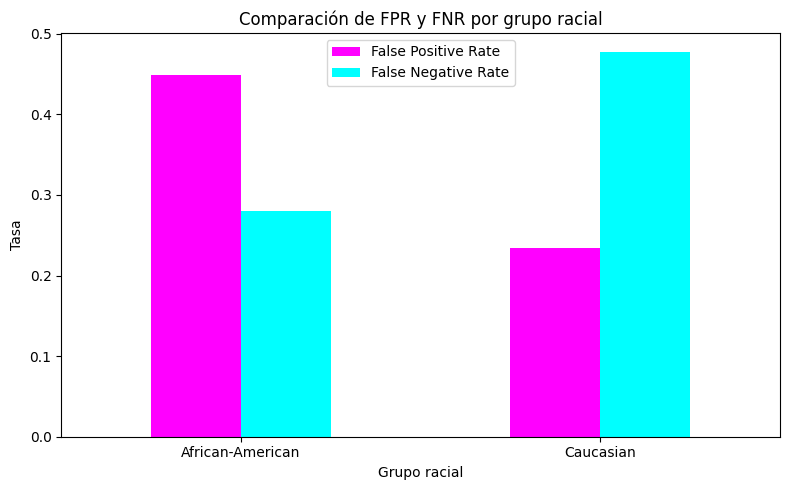

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

error_by_race[["FPR", "FNR"]].plot(kind="bar", ax=ax, color=["magenta", "aqua"])

ax.set_title("Comparación de FPR y FNR por grupo racial")
ax.set_xlabel("Grupo racial")
ax.set_ylabel("Tasa")
ax.tick_params(axis="x", rotation=0)
ax.legend(["False Positive Rate", "False Negative Rate"])

plt.tight_layout()
plt.savefig("./images/compas_fpr_fnr_by_race.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### 1.7.8. Gráfica de distribución de `decile_score` por raza

Apoyando el punto anterior, se observa que la distribución de `decile_score` muestra un desplazamiento hacia puntuaciones de riesgo más altas en el grupo _African-American_ respecto al grupo _Caucasian_. Mientras que los individuos _Caucasian_ se concentran principalmente en puntuaciones bajas e intermedias, el grupo _African-American_ presenta una mayor densidad en valores altos del score COMPAS.

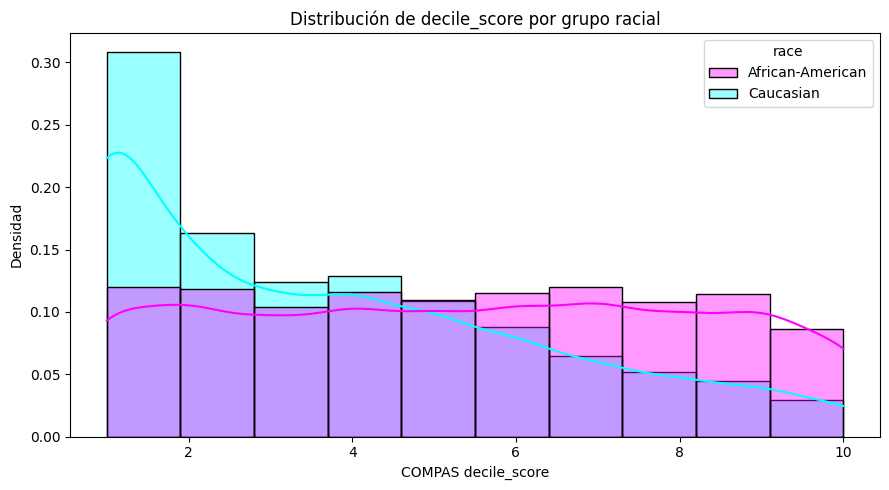

In [ ]:
# Distribución de decile_score por raza: African-American vs Caucasian

df_race_compare = df_compas[
    df_compas["race"].isin(["African-American", "Caucasian"])
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df_race_compare,
    x="decile_score",
    hue="race",
    stat="density",
    common_norm=False,
    kde=True,
    bins=10,
    alpha=0.4,
    ax=ax,
    palette={
      "African-American": "magenta",
      "Caucasian": "aqua"
  },
)

ax.set_title("Distribución de decile_score por grupo racial")
ax.set_xlabel("COMPAS decile_score")
ax.set_ylabel("Densidad")

plt.tight_layout()
plt.savefig(
    "./images/compas_score_distribution_by_race.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### 1.7.9. Matriz de correlación

La matriz de correlación muestra  que `priors_count` y `decile_score` presentan correlación positiva con la variable objetivo `two_year_recid`, lo que indica que los antecedentes previos y la puntuación COMPAS están asociados con mayor probabilidad de reincidencia. La edad presenta una relación negativa con la reincidencia, sugiriendo que los individuos más jóvenes tienden a reincidir con mayor frecuencia. Las correlaciones de variables categóricas codificadas deben interpretarse con cautela, ya que la codificación numérica no implica un orden real entre categorías. Por este motivo, estas se interpretan sólo como una aproximación exploratoria y no como evidencia estadística concluyente.

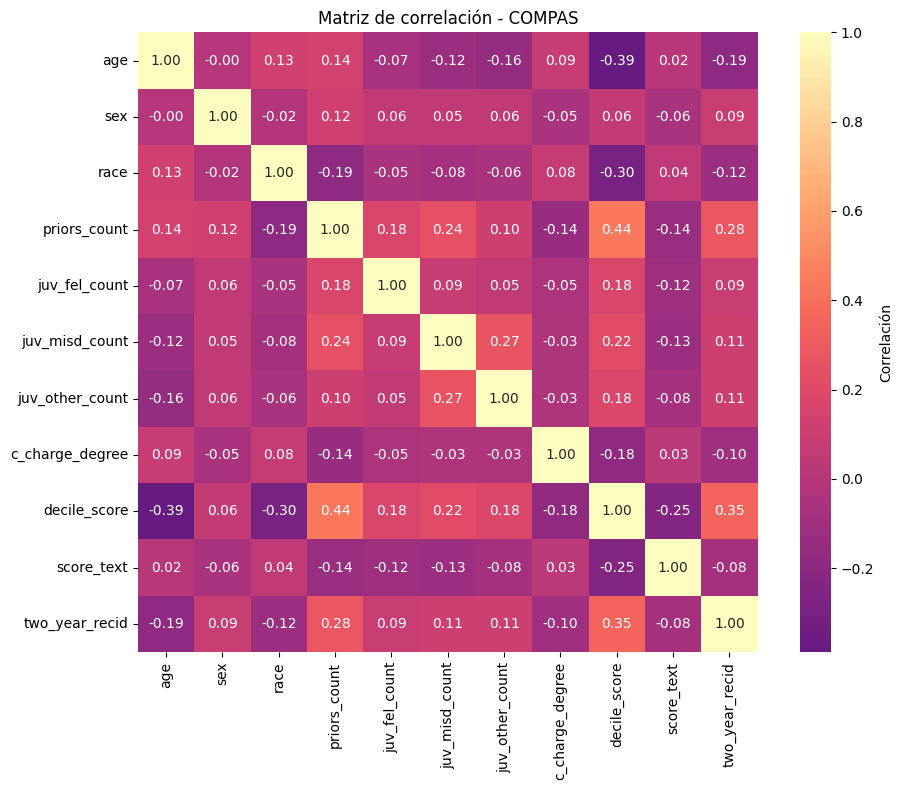

In [ ]:
# CM
df_corr = df_compas.copy()

# Codificación simple para análisis exploratorio.
categorical_cols = ["sex", "race", "c_charge_degree", "score_text"]

for col in categorical_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    center=0,
    square=True,
    ax=ax,
    cbar_kws={"label": "Correlación"}
)

ax.set_title("Matriz de correlación - COMPAS")

plt.tight_layout()
plt.savefig("./images/compas_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### 1.7.10. Distribución de género

Al igual que con la variable sensible race, se ha querido analizar si COMPAS tiene un gran desbalance en la cantidad de falsos positivos respecto al género.

        count  percentage
sex                      
Male     5819       80.66
Female   1395       19.34


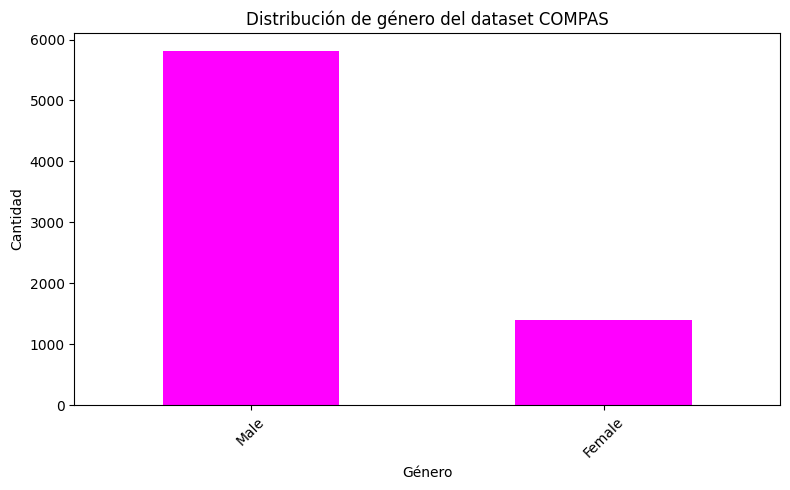

In [ ]:
# Plot Distribución género
race_counts = df_compas["sex"].value_counts()
race_pct = df_compas["sex"].value_counts(normalize=True) * 100

race_table = pd.DataFrame({
    "count": race_counts,
    "percentage": race_pct.round(2)
})

print(race_table)

fig, ax = plt.subplots(figsize=(8, 5))

race_counts.plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Distribución de género del dataset COMPAS")
ax.set_xlabel("Género")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./images/compas_race_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 1.7.11. Tasa de reincidencia por sexo

        count      mean  recidivism_rate_%
sex                                       
Male     5819  0.473105              47.31
Female   1395  0.356989              35.70


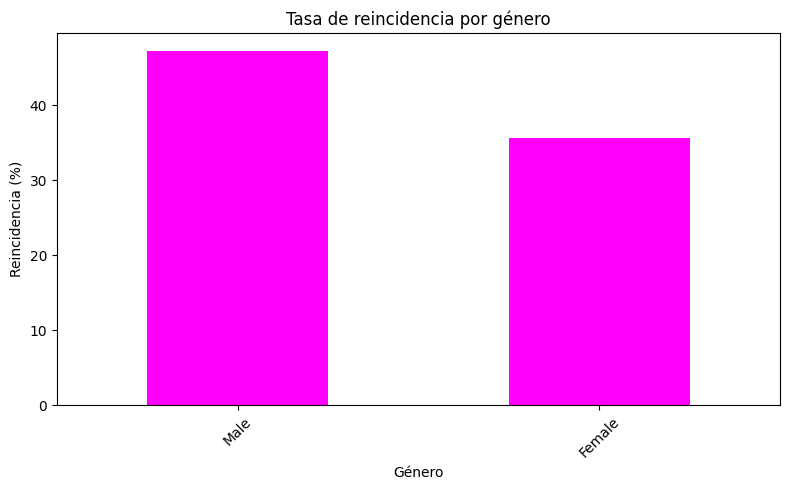

In [ ]:
# Plot. Tasa de reincidencia por grupo racial
recid_by_sex = (
    df_compas.groupby("sex")["two_year_recid"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

recid_by_sex["recidivism_rate_%"] = (recid_by_sex["mean"] * 100).round(2)

print(recid_by_sex)

fig, ax = plt.subplots(figsize=(8, 5))

recid_by_sex["recidivism_rate_%"].plot(kind="bar", ax=ax, color="magenta")

ax.set_title("Tasa de reincidencia por género")
ax.set_xlabel("Género")
ax.set_ylabel("Reincidencia (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./images/compas_recidivism_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 1.7.12.  Comparación FPR y FNR por sexo

 Aunque, como se observa en la gráfica obtenida, las disparidades son considerablemente menores que las detectadas entre grupos raciales. Por ello, el proyecto se centrará específicamente en la variable sensible `race`.

In [ ]:
# FPR y FNR por sexo usando COMPAS
# Dos grupos principales
df_ac = df_compas[
    df_compas["sex"].isin(["Male", "Female"])
].copy()

# Convertimos COMPAS en predicción binaria:
# Medium/High -> 1
# Low -> 0
df_ac["compas_pred"] = (
    df_ac["score_text"]
    .isin(["Medium", "High"])
    .astype(int)
)

def calcular_metricas_grupo(group):

    # Confusion matrix manual
    fp = (
        (group["compas_pred"] == 1) &
        (group["two_year_recid"] == 0)
    ).sum()

    tn = (
        (group["compas_pred"] == 0) &
        (group["two_year_recid"] == 0)
    ).sum()

    fn = (
        (group["compas_pred"] == 0) &
        (group["two_year_recid"] == 1)
    ).sum()

    tp = (
        (group["compas_pred"] == 1) &
        (group["two_year_recid"] == 1)
    ).sum()

    # Métricas
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return pd.Series({
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": accuracy
    })

# Aplicamos por sexo
error_by_sex = (
    df_ac
    .groupby("sex")
    .apply(calcular_metricas_grupo)
)

display(error_by_sex.round(3))

/tmp/ipykernel_11157/3981878697.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_metricas_grupo)


,FP,TN,FN,TP,FPR,FNR,Accuracy
sex,,,,,,,
Female,288.0,609.0,195.0,303.0,0.321,0.392,0.654
Male,994.0,2072.0,1021.0,1732.0,0.324,0.371,0.654


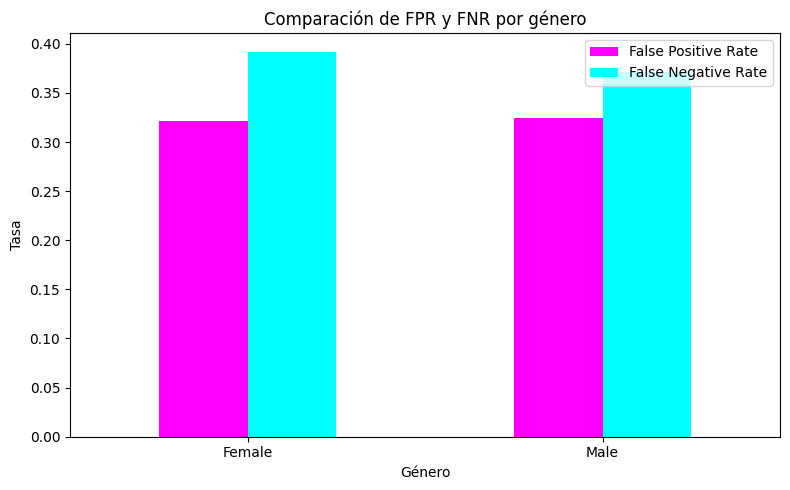

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

error_by_sex[["FPR", "FNR"]].plot(kind="bar", ax=ax, color=["magenta", "aqua"])

ax.set_title("Comparación de FPR y FNR por género")
ax.set_xlabel("Género")
ax.set_ylabel("Tasa")
ax.tick_params(axis="x", rotation=0)
ax.legend(["False Positive Rate", "False Negative Rate"])

plt.tight_layout()
plt.savefig("./images/compas_fpr_fnr_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 2. Clasificadores estándar

En esta sección se entrenan **cinco clasificadores** para predecir la reincidencia a dos años (`two_year_recid`) y analizar si reproducen los sesgos detectados en COMPAS. La elección de modelos **no es arbitraria**: se fundamenta en la literatura específica sobre predicción de reincidencia y auditoría del propio sistema COMPAS.

**Justificación bibliográfica de los modelos elegidos:**

- **Regresión Logística** y **SVM con kernel RBF**: son exactamente los dos clasificadores empleados por Dressel & Farid (2018) en *«The accuracy, fairness, and limits of predicting recidivism»* (*Science Advances*), el estudio de referencia que replicó COMPAS. Demostraron que un predictor lineal con pocas variables iguala la precisión de COMPAS (≈65%), y que el SVM no lineal **no mejora** ese techo, lo que evidencia que el límite lo impone el dato y no el modelo. Incluir ambos permite reproducir y contrastar ese hallazgo central.
- **Random Forest**: en la revisión sistemática de Travaini et al. (2022, *International Journal of Environmental Research and Public Health*) es el método de *ensemble* más utilizado para reincidencia (mejor modelo en 4 de los estudios revisados), justo después de la regresión logística.
- **XGBoost (Gradient Boosting)**: Tollenaar & van der Heijden (2019, *PLOS One*) reportan que el *boosting* de gradiente optimizado obtiene el mejor poder predictivo (mayor R²) sobre datos de reincidencia, por encima de Random Forest y modelos penalizados.
- **Multi-Layer Perceptron (red neuronal)**: incluido también en la revisión de Travaini et al. (2022) como representante de los modelos no lineales tipo red neuronal, para comprobar si una mayor capacidad de representación altera precisión o equidad.

La conclusión transversal de esta literatura es que **la complejidad del modelo apenas mejora la predicción de reincidencia**; por eso el diseño compara deliberadamente un *baseline* lineal interpretable frente a modelos progresivamente más complejos. Las variables derivadas de COMPAS (`decile_score`, `score_text`) se excluyen para construir clasificadores independientes. Todos los modelos se optimizan mediante **GridSearchCV con validación cruzada estratificada de 5 *folds*** (métrica de selección: AUC-ROC) y se evalúan con métricas estándar y análisis de *fairness* por grupo racial.

### 2.1. Preprocesamiento para modelado

Se eliminan los 1103 duplicados detectados en el EDA. Las variables derivadas de COMPAS (`decile_score` y `score_text`) se excluyen intencionadamente para construir un clasificador independiente del sistema que se analiza. Las variables binarias `sex` y `c_charge_degree` se codifican numéricamente (0/1), mientras que `race` se transforma mediante _one-hot encoding_. La columna `race` original se conserva por separado para el análisis de _fairness_ posterior. La partición train/test es 80/20 con estratificación sobre la variable objetivo.

El escalado de variables (`StandardScaler`) se aplica **dentro de un `Pipeline`** para los modelos sensibles a la escala (Regresión Logística, SVM y MLP), de forma que el ajuste del escalador ocurre solo con los datos de entrenamiento de cada *fold* de la validación cruzada y **no hay fuga de información**. Random Forest y XGBoost son invariantes a transformaciones monótonas, por lo que no requieren escalado.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score
)
from xgboost import XGBClassifier

# --- Preprocesamiento ---
df_model = df_compas.drop_duplicates().copy()
print(f"Shape tras eliminar duplicados: {df_model.shape}")

features_model = [
    "age", "sex", "race", "priors_count",
    "juv_fel_count", "juv_misd_count", "juv_other_count", "c_charge_degree"
]

X = df_model[features_model].copy()
y = df_model["two_year_recid"].copy()

# Guardar race antes de codificar para la evaluación de fairness posterior
race_col = X["race"].copy()

# Codificación binaria de variables de dos categorías
X["sex"] = (X["sex"] == "Male").astype(int)
X["c_charge_degree"] = (X["c_charge_degree"] == "F").astype(int)

# One-hot encoding para race (mantenida en el modelo para analizar su influencia)
X = pd.get_dummies(X, columns=["race"], drop_first=False)
X = X.astype(int)

print(f"Features del modelo: {list(X.columns)}")
print(f"\nDistribución del target tras limpieza:")
print(y.value_counts(normalize=True).round(3))

# Split estratificado 80/20
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race_col, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# --- Validación cruzada y utilidades de GridSearch ---
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Orden fijo de los modelos para todas las comparativas posteriores
MODELOS_ORDEN = [
    "Logistic Regression", "SVM (RBF)", "Random Forest", "XGBoost", "MLP"
]
estimadores, predicciones, scores_prob, mejores_params = {}, {}, {}, {}

def _scores_positivos(est, X):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    return est.decision_function(X)

def entrenar_grid(nombre, pipeline, param_grid):
    grid = GridSearchCV(
        pipeline, param_grid,
        cv=CV, scoring="roc_auc",
        n_jobs=-1, refit=True
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    y_prob = _scores_positivos(best, X_test)

    estimadores[nombre] = best
    predicciones[nombre] = y_pred
    scores_prob[nombre] = y_prob
    mejores_params[nombre] = grid.best_params_

    print(f"=== {nombre} ===")
    print(f"Mejor AUC-ROC (CV 5-fold): {grid.best_score_:.4f}")
    print(f"Mejores hiperparámetros: {grid.best_params_}")
    print(classification_report(y_test, y_pred, target_names=["No reincide", "Reincide"]))
    print(f"AUC-ROC (test): {roc_auc_score(y_test, y_prob):.4f}")
    return best

Shape tras eliminar duplicados: (6111, 11)
Features del modelo: ['age', 'sex', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']

Distribución del target tras limpieza:
two_year_recid
0    0.517
1    0.483
Name: proportion, dtype: float64

Train: (4888, 13) | Test: (1223, 13)


### 2.2. Logistic Regression

La regresión logística modela la probabilidad de reincidencia como una función sigmoide de una combinación lineal de las variables de entrada. Es el **_baseline_ interpretable** y el modelo de referencia en la literatura de *fairness* judicial (Dressel & Farid, 2018; Travaini et al., 2022):

- Sus **coeficientes son directamente legibles**: se puede cuantificar el peso de cada variable — incluidas las columnas derivadas de `race` — en la predicción, lo que permite **detectar sesgo explícito**.
- Actúa como **cota inferior de rendimiento**: si los modelos más complejos no la superan, la complejidad añadida no está justificada — precisamente la tesis de Dressel & Farid.

Se optimiza con **GridSearchCV (5-fold)** sobre la regularización (`C`), el tipo de penalización (`l1`/`l2`) y el reequilibrio de clases (`class_weight`), con escalado previo dentro del *pipeline*.

In [ ]:
# Logistic Regression — GridSearchCV 5-fold
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
lr_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": [None, "balanced"],
}
entrenar_grid("Logistic Regression", lr_pipe, lr_grid)

=== Logistic Regression ===
Mejor AUC-ROC (CV 5-fold): 0.7108
Mejores hiperparámetros: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
              precision    recall  f1-score   support

 No reincide       0.64      0.67      0.66       632
    Reincide       0.63      0.60      0.61       591

    accuracy                           0.64      1223
   macro avg       0.63      0.63      0.63      1223
weighted avg       0.64      0.64      0.63      1223

AUC-ROC (test): 0.6857


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=5000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

### 2.3. Support Vector Machine (kernel RBF)

El SVM con kernel RBF busca un hiperplano de máximo margen en un espacio de características no lineal. Es el **segundo clasificador empleado por Dressel & Farid (2018)** en su auditoría de COMPAS: lo usaron como modelo no lineal de contraste frente a la regresión logística. Su resultado clave —que el SVM no lineal **no superó** al predictor lineal— sustenta la conclusión de que el límite predictivo lo impone el propio dato. Incluirlo aquí permite **replicar ese contraste lineal vs. no lineal** sobre los mismos datos.

Se optimiza con **GridSearchCV (5-fold)** sobre `C` (regularización), `gamma` (alcance del kernel) y `class_weight`, con escalado previo (imprescindible para SVM). La separabilidad por AUC se evalúa vía `decision_function`.

In [ ]:
# Support Vector Machine (kernel RBF) — GridSearchCV 5-fold
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE)),
])
svm_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "clf__class_weight": [None, "balanced"],
}
entrenar_grid("SVM (RBF)", svm_pipe, svm_grid)

=== SVM (RBF) ===
Mejor AUC-ROC (CV 5-fold): 0.7098
Mejores hiperparámetros: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.001}
              precision    recall  f1-score   support

 No reincide       0.64      0.70      0.67       632
    Reincide       0.64      0.58      0.61       591

    accuracy                           0.64      1223
   macro avg       0.64      0.64      0.64      1223
weighted avg       0.64      0.64      0.64      1223

AUC-ROC (test): 0.6931


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 SVC(C=100, class_weight='balanced', gamma=0.001,
                     random_state=42))])

### 2.4. Random Forest

Random Forest es un método de _ensemble_ que entrena múltiples árboles de decisión sobre subconjuntos aleatorios de datos y variables, agregando sus predicciones por votación. Reduce la varianza respecto a un árbol individual y es robusto frente a valores extremos. En la revisión sistemática de Travaini et al. (2022) es el **método de *ensemble* más usado** en predicción de reincidencia tras la regresión logística, lo que lo hace una comparación obligada.

Se optimiza con **GridSearchCV (5-fold)** sobre el número de árboles, la profundidad máxima, el mínimo de muestras por división y el número de variables candidatas por nodo. No requiere escalado.

In [ ]:
# Random Forest — GridSearchCV 5-fold
rf_pipe = Pipeline([
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_grid = {
    "clf__n_estimators": [100, 300, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
}
entrenar_grid("Random Forest", rf_pipe, rf_grid)

=== Random Forest ===
Mejor AUC-ROC (CV 5-fold): 0.7025
Mejores hiperparámetros: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
              precision    recall  f1-score   support

 No reincide       0.63      0.71      0.67       632
    Reincide       0.64      0.56      0.60       591

    accuracy                           0.64      1223
   macro avg       0.64      0.63      0.63      1223
weighted avg       0.64      0.64      0.63      1223

AUC-ROC (test): 0.6885


Pipeline(steps=[('clf',
                 RandomForestClassifier(max_depth=10, min_samples_split=10,
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])

### 2.5. XGBoost

XGBoost (_Extreme Gradient Boosting_) construye árboles secuencialmente, cada uno corrigiendo los errores del anterior mediante descenso de gradiente con regularización. Tollenaar & van der Heijden (2019, *PLOS One*) reportan que el *gradient boosting* optimizado obtiene el **mejor poder predictivo** sobre datos de reincidencia (mayor R²), por encima de Random Forest y modelos penalizados, lo que lo convierte en el representante del estado del arte en datos tabulares para este problema.

Se optimiza con **GridSearchCV (5-fold)** sobre número de árboles, profundidad, tasa de aprendizaje y submuestreo de filas/columnas. No requiere escalado.

In [ ]:
# XGBoost — GridSearchCV 5-fold
xgb_pipe = Pipeline([
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0
    )),
])
xgb_grid = {
    "clf__n_estimators": [100, 300, 500],
    "clf__max_depth": [3, 6, 9],
    "clf__learning_rate": [0.01, 0.1, 0.3],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}
entrenar_grid("XGBoost", xgb_pipe, xgb_grid)

=== XGBoost ===
Mejor AUC-ROC (CV 5-fold): 0.7171
Mejores hiperparámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
              precision    recall  f1-score   support

 No reincide       0.64      0.72      0.68       632
    Reincide       0.66      0.57      0.61       591

    accuracy                           0.65      1223
   macro avg       0.65      0.65      0.64      1223
weighted avg       0.65      0.65      0.65      1223

AUC-ROC (test): 0.6972


Pipeline(steps=[('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1.0, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

### 2.6. Multi-Layer Perceptron (red neuronal)

El MLP es una red neuronal _feed-forward_ con capas ocultas y activaciones no lineales, capaz de aproximar fronteras de decisión arbitrarias. Travaini et al. (2022) lo incluyen como representante de los modelos tipo red neuronal en su revisión. Sirve para comprobar si una capacidad de representación mucho mayor mejora —o no— precisión y equidad respecto a los modelos más simples, reforzando (o refutando) la tesis de que la complejidad apenas aporta en este problema.

Se optimiza con **GridSearchCV (5-fold)** sobre la arquitectura (capas ocultas), la regularización `alpha`, la función de activación y la tasa de aprendizaje inicial, con escalado previo y *early stopping* para controlar el sobreajuste.

In [ ]:
# Multi-Layer Perceptron — GridSearchCV 5-fold
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        max_iter=1000, early_stopping=True, random_state=RANDOM_STATE
    )),
])
mlp_grid = {
    "clf__hidden_layer_sizes": [(50,), (100,), (100, 50), (50, 50)],
    "clf__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    "clf__activation": ["relu", "tanh"],
    "clf__learning_rate_init": [1e-3, 1e-2],
}
entrenar_grid("MLP", mlp_pipe, mlp_grid)

=== MLP ===
Mejor AUC-ROC (CV 5-fold): 0.7115
Mejores hiperparámetros: {'clf__activation': 'tanh', 'clf__alpha': 0.1, 'clf__hidden_layer_sizes': (50, 50), 'clf__learning_rate_init': 0.01}
              precision    recall  f1-score   support

 No reincide       0.65      0.68      0.66       632
    Reincide       0.64      0.60      0.62       591

    accuracy                           0.64      1223
   macro avg       0.64      0.64      0.64      1223
weighted avg       0.64      0.64      0.64      1223

AUC-ROC (test): 0.6979


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 MLPClassifier(activation='tanh', alpha=0.1,
                               early_stopping=True, hidden_layer_sizes=(50, 50),
                               learning_rate_init=0.01, max_iter=1000,
                               random_state=42))])

### 2.7. Comparación de métricas

Se comparan los cinco clasificadores (con hiperparámetros ya optimizados por GridSearchCV) mediante accuracy, precision, recall, F1-score y AUC-ROC. Dado el desbalance moderado del dataset (~45% positivos), el F1-score y el AUC-ROC son métricas más informativas que el accuracy aislado. Según la literatura, se espera que las diferencias de rendimiento entre modelos sean pequeñas.

,Accuracy,Precision,Recall,F1,AUC-ROC
Logistic Regression,0.6353,0.6292,0.5973,0.6128,0.6857
SVM (RBF),0.6402,0.6417,0.5787,0.6085,0.6931
Random Forest,0.6361,0.6420,0.5584,0.5973,0.6885
XGBoost,0.6484,0.6575,0.5685,0.6098,0.6972
MLP,0.6427,0.6390,0.5990,0.6183,0.6979


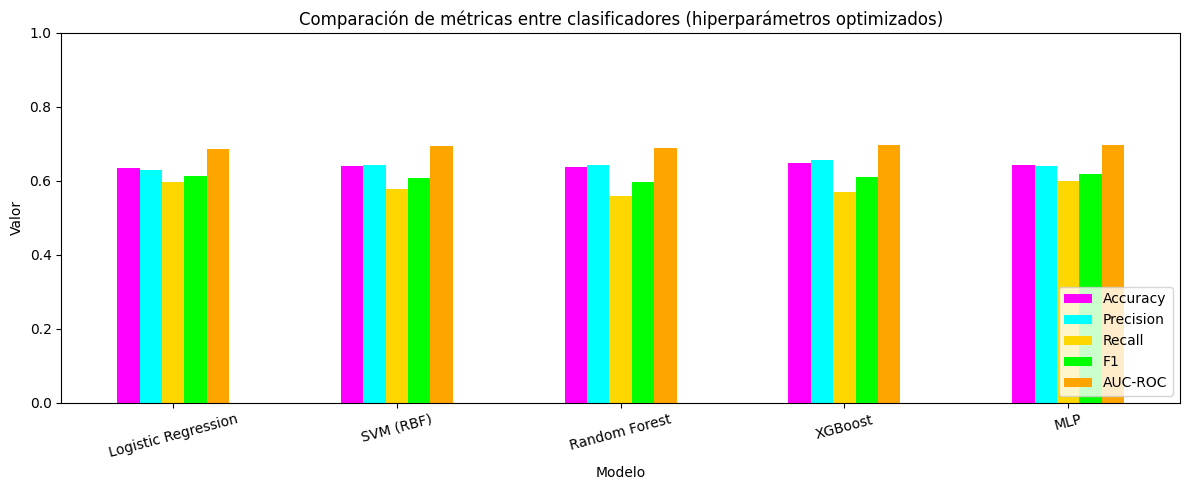

In [ ]:
# Tabla comparativa de métricas
def calcular_metricas(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
    }

tabla_resultados = pd.DataFrame({
    nombre: calcular_metricas(y_test, predicciones[nombre], scores_prob[nombre])
    for nombre in MODELOS_ORDEN
}).T

display(tabla_resultados.round(4))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 5))

tabla_resultados.plot(kind="bar", ax=ax,
                      color=["magenta", "aqua", "gold", "lime", "orange"])
ax.set_title("Comparación de métricas entre clasificadores (hiperparámetros optimizados)")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
ax.tick_params(axis="x", rotation=15)
ax.legend(loc="lower right")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("./images/metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 3. Mitigación de sesgo con Fairlearn

En esta sección se aplican técnicas de preprocesamiento y postprocesamiento de la librería **Fairlearn** para reducir la disparidad de predicciones entre grupos raciales. El objetivo no es únicamente maximizar la exactitud del modelo, sino lograr un equilibrio entre rendimiento predictivo y equidad (_fairness_).

Se utilizan dos enfoques complementarios:

- **Preprocesamiento**: `CorrelationRemover`, que transforma las variables de entrada para reducir su correlación con el atributo sensible `race`, mitigando la discriminación por _proxy_ sin eliminar directamente la variable del modelo.
- **Postprocesamiento**: `ThresholdOptimizer`, que ajusta los umbrales de decisión de un clasificador ya entrenado para que las métricas de equidad se igualen entre grupos raciales.

El atributo sensible empleado en todos los experimentos es `race`, restringido a los dos grupos mayoritarios del dataset (_African-American_ y _Caucasian_) para garantizar estimaciones estadísticamente robustas.

### 3.1.Imports

In [ ]:
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    MetricFrame,
    false_positive_rate,
    false_negative_rate,
    equalized_odds_difference,
    demographic_parity_difference
)
import warnings
warnings.filterwarnings('ignore')

### 3.2. Preparación del subconjunto African-American / Caucasian

Se filtra el dataset a los dos grupos raciales mayoritarios para garantizar estimaciones estadísticamente robustas. Se reutiliza el mismo preprocesamiento del apartado anterior (codificación binaria de `sex` y `c_charge_degree`, _one-hot_ de `race`), conservando la columna `race` original para usarla como atributo sensible en las métricas de equidad.

In [ ]:
# Filtrar a los dos grupos mayoritarios
df_fair = df_model[df_model['race'].isin(['African-American', 'Caucasian'])].copy()
print(f'Shape tras filtrar grupos mayoritarios: {df_fair.shape}')
print(df_fair['race'].value_counts())

# Guardar atributo sensible antes de codificar
sensitive_col = df_fair['race'].copy()

# Preprocesamiento idéntico al del apartado de clasificadores
X_fair = df_fair[features_model].copy()
y_fair = df_fair['two_year_recid'].copy()

X_fair['sex'] = (X_fair['sex'] == 'Male').astype(int)
X_fair['c_charge_degree'] = (X_fair['c_charge_degree'] == 'F').astype(int)
X_fair = pd.get_dummies(X_fair, columns=['race'], drop_first=False).astype(int)

X_f_train, X_f_test, y_f_train, y_f_test, sens_train, sens_test = train_test_split(
    X_fair, y_fair, sensitive_col,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_fair
)

print(f'\nTrain: {X_f_train.shape} | Test: {X_f_test.shape}')

Shape tras filtrar grupos mayoritarios: (5142, 11)
race
African-American    3138
Caucasian           2004
Name: count, dtype: int64

Train: (4113, 9) | Test: (1029, 9)


In [ ]:
def metricas_equidad(y_true, y_pred, sensitive):
    """Calcula métricas de equidad por grupo sensible mediante MetricFrame."""
    mf = MetricFrame(
        metrics={
            'FPR': false_positive_rate,
            'FNR': false_negative_rate,
            'Accuracy': accuracy_score
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    return mf, eod, dpd

### 3.3. Baseline con LR

In [ ]:
# Logistic Regression
lr_f = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_f.fit(X_f_train, y_f_train)

y_pred_f_lr = lr_f.predict(X_f_test)
y_prob_f_lr = lr_f.predict_proba(X_f_test)[:, 1]

mf_lr, eod_lr, dpd_lr = metricas_equidad(y_f_test, y_pred_f_lr, sens_test)

print("=== Logistic Regression ===")
print(classification_report(y_f_test, y_pred_f_lr, target_names=["No reincide", "Reincide"]))
print(f"AUC-ROC: {roc_auc_score(y_f_test, y_prob_f_lr):.4f}")
print(f'Equalized Odds Difference  : {eod_lr:.4f}')
print(f'Demographic Parity Diff.   : {dpd_lr:.4f}')
print('\nMétricas por grupo:')
display(mf_lr.by_group.round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

 No reincide       0.64      0.66      0.65       512
    Reincide       0.65      0.64      0.65       517

    accuracy                           0.65      1029
   macro avg       0.65      0.65      0.65      1029
weighted avg       0.65      0.65      0.65      1029

AUC-ROC: 0.6810
Equalized Odds Difference  : 0.2908
Demographic Parity Diff.   : 0.2531

Métricas por grupo:


,FPR,FNR,Accuracy
race,,,
African-American,0.4236,0.2492,0.6678
Caucasian,0.2366,0.5400,0.6203


### 3.4. Preprocesamiento: CorrelationRemover

`CorrelationRemover` proyecta el espacio de características para eliminar la correlación lineal entre las variables de entrada y el atributo sensible. A diferencia de eliminar directamente las columnas de `race`, actúa sobre _todas_ las variables, reduciendo la información que el modelo puede usar para inferir el grupo racial de forma indirecta (_proxy discrimination_).

El parámetro `alpha` controla el grado de eliminación: `alpha=1.0` elimina completamente la correlación lineal con el atributo sensible, mientras que valores menores permiten un compromiso entre equidad y rendimiento. Se usa `alpha=1.0` como punto de partida.

In [ ]:
# CorrelationRemover requiere el atributo sensible como array numérico
sensitive_train_num = (sens_train == 'African-American').astype(int).values
sensitive_test_num  = (sens_test  == 'African-American').astype(int).values

# Aplicar CorrelationRemover sobre las columnas de raza
race_cols = ['race_African-American', 'race_Caucasian']
cr = CorrelationRemover(sensitive_feature_ids=race_cols)
X_cr_train = cr.fit_transform(X_f_train)
X_cr_test  = cr.transform(X_f_test)

# Entrenar clasificador sobre las features transformadas
lr_cr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cr.fit(X_cr_train, y_f_train)

y_pred_cr = lr_cr.predict(X_cr_test)
y_prob_cr = lr_cr.predict_proba(X_cr_test)[:, 1]

mf_cr, eod_cr, dpd_cr = metricas_equidad(y_f_test, y_pred_cr, sens_test)

print('=== CorrelationRemover (alpha=1.0) ===')
print(classification_report(y_f_test, y_pred_cr, target_names=["No reincide", "Reincide"]))
print(f"AUC-ROC: {roc_auc_score(y_f_test, y_prob_cr):.4f}")
print(f'Equalized Odds Difference  : {eod_cr:.4f}')
print(f'Demographic Parity Diff.   : {dpd_cr:.4f}')
print('\nMétricas por grupo:')
display(mf_cr.by_group.round(4))

=== CorrelationRemover (alpha=1.0) ===
              precision    recall  f1-score   support

 No reincide       0.64      0.62      0.63       512
    Reincide       0.64      0.65      0.64       517

    accuracy                           0.64      1029
   macro avg       0.64      0.64      0.64      1029
weighted avg       0.64      0.64      0.64      1029

AUC-ROC: 0.6815
Equalized Odds Difference  : 0.2639
Demographic Parity Diff.   : 0.1941

Métricas por grupo:


,FPR,FNR,Accuracy
race,,,
African-American,0.4201,0.2461,0.6711
Caucasian,0.3214,0.5100,0.5896


,Accuracy,F1,EOD,DPD
alpha,,,,
0.00,0.6492,0.6471,0.2858,0.2507
0.25,0.6463,0.6445,0.2663,0.2323
0.50,0.6395,0.6422,0.2513,0.2016
0.75,0.6414,0.6455,0.2608,0.2002
1.00,0.6375,0.6437,0.2639,0.1941


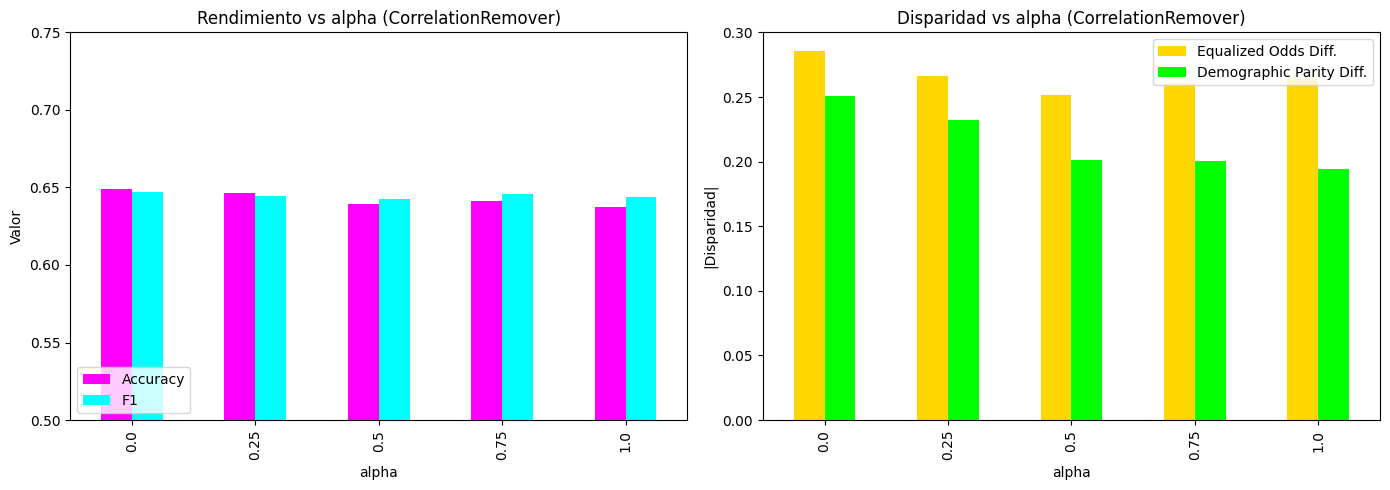

In [ ]:
# Análisis del efecto de alpha en CorrelationRemover
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
resultados_alpha = []

for alpha in alphas:
    cr_a = CorrelationRemover(sensitive_feature_ids=race_cols, alpha=alpha)
    X_cr_a_train = cr_a.fit_transform(X_f_train)
    X_cr_a_test  = cr_a.transform(X_f_test)

    lr_a = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_a.fit(X_cr_a_train, y_f_train)
    y_pred_a = lr_a.predict(X_cr_a_test)

    _, eod_a, dpd_a = metricas_equidad(y_f_test, y_pred_a, sens_test)

    resultados_alpha.append({
        "alpha": alpha,
        "Accuracy": accuracy_score(y_f_test, y_pred_a),
        "F1": f1_score(y_f_test, y_pred_a),
        "EOD": eod_a,
        "DPD": dpd_a
    })

df_alpha = pd.DataFrame(resultados_alpha).set_index("alpha")
display(df_alpha.round(4))

# Gráfico trade-off alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_alpha[["Accuracy", "F1"]].plot(
    ax=axes[0], color=["magenta", "aqua"], kind="bar"
)
axes[0].set_title("Rendimiento vs alpha (CorrelationRemover)")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Valor")
axes[0].set_ylim(0.5, 0.75)
axes[0].legend(loc="lower left")

df_alpha[["EOD", "DPD"]].abs().plot(
    ax=axes[1], color=["gold", "lime"], kind="bar"
)
axes[1].set_title("Disparidad vs alpha (CorrelationRemover)")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("|Disparidad|")
axes[1].legend(["Equalized Odds Diff.", "Demographic Parity Diff."], loc="upper right")

plt.tight_layout()
plt.savefig("./images/fairlearn_alpha_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 3.5. Postprocesamiento: ThresholdOptimizer

`ThresholdOptimizer` aplica umbrales de decisión distintos para cada grupo sensible, de forma que el modelo satisfaga una restricción de equidad especificada. A diferencia del preprocesamiento, no modifica el entrenamiento del modelo sino su función de decisión en inferencia.

Se utiliza la restricción `equalized_odds`, que exige igualar simultáneamente la FPR y la FNR entre grupos. El objetivo de optimización es `balanced_accuracy_score` para compensar el ligero desbalance del dataset.


In [ ]:
# ThresholdOptimizer con restricción equalized_odds
to = ThresholdOptimizer(
    estimator=lr_f,
    constraints='equalized_odds',
    objective='balanced_accuracy_score',
    predict_method='predict_proba'
)

to.fit(X_f_train, y_f_train, sensitive_features=sens_train)
y_pred_to = to.predict(X_f_test, sensitive_features=sens_test,
                       random_state=RANDOM_STATE)

mf_to, eod_to, dpd_to = metricas_equidad(y_f_test, y_pred_to, sens_test)

print('=== ThresholdOptimizer (equalized_odds) ===')
print(classification_report(y_f_test, y_pred_to, target_names=["No reincide", "Reincide"]))
print(f'Equalized Odds Difference  : {eod_to:.4f}')
print(f'Demographic Parity Diff.   : {dpd_to:.4f}')
print('\nMétricas por grupo:')
display(mf_cr.by_group.round(4))

=== ThresholdOptimizer (equalized_odds) ===
              precision    recall  f1-score   support

 No reincide       0.60      0.64      0.62       512
    Reincide       0.62      0.58      0.60       517

    accuracy                           0.61      1029
   macro avg       0.61      0.61      0.61      1029
weighted avg       0.61      0.61      0.61      1029

Equalized Odds Difference  : 0.0983
Demographic Parity Diff.   : 0.0562

Métricas por grupo:


,FPR,FNR,Accuracy
race,,,
African-American,0.4201,0.2461,0.6711
Caucasian,0.3214,0.5100,0.5896


,Accuracy,F1,EOD,DPD,FPR_AA,FPR_CA,FNR_AA,FNR_CA
Restricción,,,,,,,,
equalized_odds,0.6113,0.6000,0.0983,0.0562,0.3542,0.3616,0.3817,0.480
demographic_parity,0.6327,0.6519,0.0709,0.0022,0.3889,0.4598,0.2997,0.340
false_positive_rate_parity,0.6278,0.6314,0.1703,0.1087,0.3889,0.3661,0.2997,0.470
true_positive_rate_parity,0.6190,0.6024,0.0807,0.0251,0.3125,0.3661,0.3943,0.475


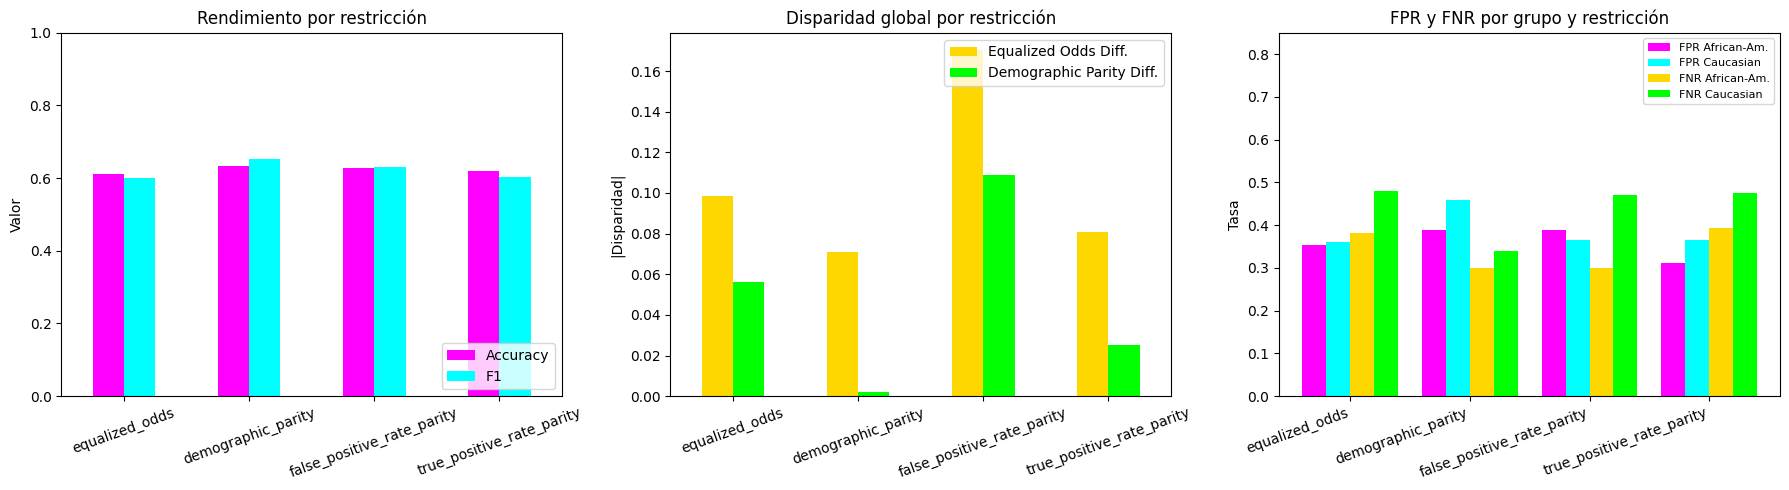

In [ ]:
# Comparación de restricciones en ThresholdOptimizer
restricciones = ["equalized_odds", "demographic_parity", "false_positive_rate_parity", "true_positive_rate_parity"]
resultados_to = []

for restriccion in restricciones:
    to_r = ThresholdOptimizer(
        estimator=lr_f,
        constraints=restriccion,
        objective="balanced_accuracy_score",
        predict_method="predict_proba"
    )
    to_r.fit(X_f_train, y_f_train, sensitive_features=sens_train)
    y_pred_r = to_r.predict(X_f_test, sensitive_features=sens_test,
                            random_state=RANDOM_STATE)

    mf_r = MetricFrame(
        metrics={"FPR": false_positive_rate, "FNR": false_negative_rate},
        y_true=y_f_test,
        y_pred=y_pred_r,
        sensitive_features=sens_test
    )
    _, eod_r, dpd_r = metricas_equidad(y_f_test, y_pred_r, sens_test)

    fpr_by_group = mf_r.by_group["FPR"]
    fnr_by_group = mf_r.by_group["FNR"]

    resultados_to.append({
        "Restricción": restriccion,
        "Accuracy": accuracy_score(y_f_test, y_pred_r),
        "F1": f1_score(y_f_test, y_pred_r),
        "EOD": abs(eod_r),
        "DPD": abs(dpd_r),
        "FPR_AA": fpr_by_group.get("African-American", float("nan")),
        "FPR_CA": fpr_by_group.get("Caucasian", float("nan")),
        "FNR_AA": fnr_by_group.get("African-American", float("nan")),
        "FNR_CA": fnr_by_group.get("Caucasian", float("nan")),
    })

df_to = pd.DataFrame(resultados_to).set_index("Restricción")
display(df_to.round(4))

# Gráfico comparativo de restricciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rendimiento
df_to[["Accuracy", "F1"]].plot(kind="bar", ax=axes[0], color=["magenta", "aqua"])
axes[0].set_title("Rendimiento por restricción")
axes[0].set_xlabel("")
axes[0].set_ylabel("Valor")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(loc="lower right")

# Disparidad global
df_to[["EOD", "DPD"]].plot(kind="bar", ax=axes[1], color=["gold", "lime"])
axes[1].set_title("Disparidad global por restricción")
axes[1].set_xlabel("")
axes[1].set_ylabel("|Disparidad|")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(["Equalized Odds Diff.", "Demographic Parity Diff."], loc="upper right")

# FPR y FNR por grupo
x = range(len(df_to))
width = 0.2
labels = df_to.index.tolist()

axes[2].bar([i - 1.5*width for i in x], df_to["FPR_AA"], width, label="FPR African-Am.", color="magenta")
axes[2].bar([i - 0.5*width for i in x], df_to["FPR_CA"], width, label="FPR Caucasian",   color="aqua")
axes[2].bar([i + 0.5*width for i in x], df_to["FNR_AA"], width, label="FNR African-Am.", color="gold")
axes[2].bar([i + 1.5*width for i in x], df_to["FNR_CA"], width, label="FNR Caucasian",   color="lime")
axes[2].set_title("FPR y FNR por grupo y restricción")
axes[2].set_ylabel("Tasa")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(labels, rotation=20, ha="right")
axes[2].set_ylim(0, 0.85)
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("./images/fairlearn_restricciones_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 3.6. Comparación de los tres enfoques

Se comparan visualmente los tres enfoques — clasificador base, `CorrelationRemover` y `ThresholdOptimizer` — en términos de rendimiento predictivo global (Accuracy, F1) y métricas de equidad (_Equalized Odds Difference_, _Demographic Parity Difference_). Un valor más próximo a 0 en las métricas de equidad indica menor disparidad entre grupos raciales.


,Accuracy,F1,EOD,DPD
Base,0.6482,0.6458,0.2908,0.2908
CorrelationRemover\n(mejor alpha),0.6395,0.6422,0.2513,0.2016
ThresholdOptimizer\n(mejor restricción),0.6327,0.6519,0.0709,0.0022


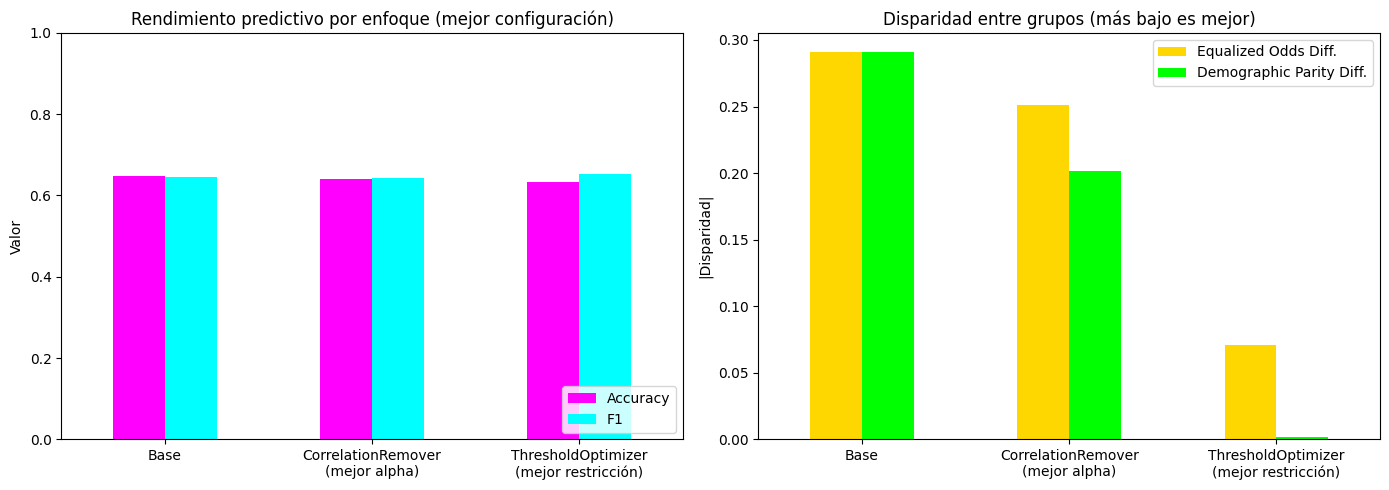

In [ ]:
# Tabla comparativa — resumen de todos los enfoques
# Se toma el alpha=1.0 de CorrelationRemover y equalized_odds de ThresholdOptimizer
# como representantes de cada técnica, consistentes con las secciones 4 y 5

tabla_fairness = pd.DataFrame({
    "Base": {
        "Accuracy": accuracy_score(y_f_test, y_pred_f_lr),
        "F1": f1_score(y_f_test, y_pred_f_lr),
        "EOD": abs(eod_lr),
        "DPD": abs(eod_lr)
    },
    "CorrelationRemover\n(mejor alpha)": {
        "Accuracy": df_alpha["Accuracy"].iloc[df_alpha["EOD"].abs().argmin()],
        "F1": df_alpha["F1"].iloc[df_alpha["EOD"].abs().argmin()],
        "EOD": df_alpha["EOD"].abs().min(),
        "DPD": df_alpha["DPD"].abs().iloc[df_alpha["EOD"].abs().argmin()]
    },
    "ThresholdOptimizer\n(mejor restricción)": {
        "Accuracy": df_to["Accuracy"].iloc[df_to["EOD"].argmin()],
        "F1": df_to["F1"].iloc[df_to["EOD"].argmin()],
        "EOD": df_to["EOD"].min(),
        "DPD": df_to["DPD"].iloc[df_to["EOD"].argmin()]
    }
}).T

display(tabla_fairness.round(4))

# Gráfico comparativo final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tabla_fairness[["Accuracy", "F1"]].plot(
    kind="bar", ax=axes[0], color=["magenta", "aqua"]
)
axes[0].set_title("Rendimiento predictivo por enfoque (mejor configuración)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Valor")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="lower right")

tabla_fairness[["EOD", "DPD"]].plot(
    kind="bar", ax=axes[1], color=["gold", "lime"]
)
axes[1].set_title("Disparidad entre grupos (más bajo es mejor)")
axes[1].set_xlabel("")
axes[1].set_ylabel("|Disparidad|")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Equalized Odds Diff.", "Demographic Parity Diff."], loc="upper right")

plt.tight_layout()
plt.savefig("./images/fairlearn_comparison_final.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 3.7. FPR y FNR por grupo racial tras mitigación

Para cada enfoque se visualiza la FPR y la FNR desagregada por grupo racial. La convergencia entre grupos en estas tasas es el indicador más directo de que la restricción `equalized_odds` ha sido satisfecha.


FPR                        FNR          
Grupo                   African-American Caucasian African-American Caucasian
Enfoque                                                                      
Base                              0.4236    0.2366           0.2492     0.540
CorrRemover\n(α=1.0)              0.4167    0.3036           0.2492     0.510
TO: FPR\nparity                   0.3889    0.3661           0.2997     0.475
TO: TPR\nparity                   0.3125    0.3705           0.3943     0.470
TO: demographic\nparity           0.3889    0.4375           0.2997     0.375
TO: equalized\nodds               0.3507    0.3616           0.4196     0.480

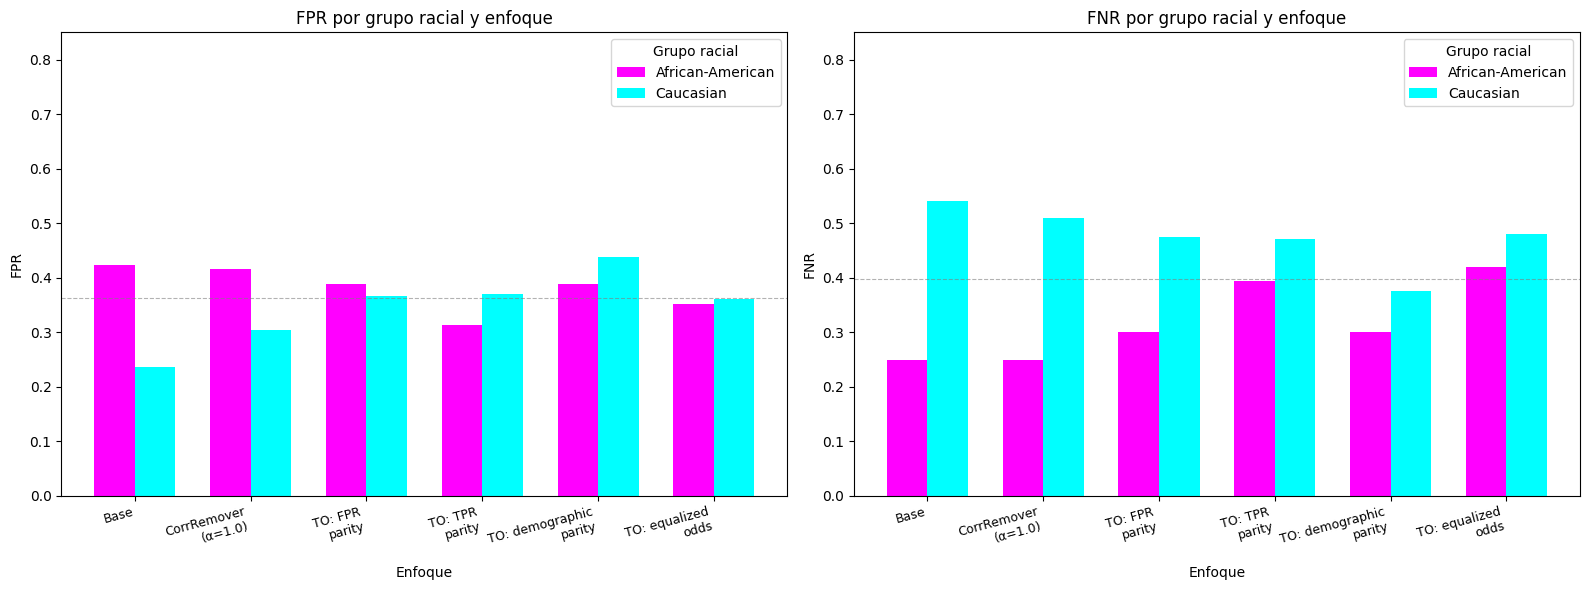

In [ ]:
# FPR y FNR por grupo racial — todos los enfoques
# Base + CorrelationRemover (alpha=1.0) + las 4 restricciones de ThresholdOptimizer

cr_final = CorrelationRemover(sensitive_feature_ids=race_cols, alpha=0.75)
X_cr_final_train = cr_final.fit_transform(X_f_train)
X_cr_final_test  = cr_final.transform(X_f_test)
lr_cr_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cr_final.fit(X_cr_final_train, y_f_train)
y_pred_cr_final = lr_cr_final.predict(X_cr_final_test)

preds_to = {}
for restriccion in ["equalized_odds", "demographic_parity",
                    "false_positive_rate_parity", "true_positive_rate_parity"]:
    to_r = ThresholdOptimizer(
        estimator=lr_f,
        constraints=restriccion,
        objective="balanced_accuracy_score",
        predict_method="predict_proba"
    )
    to_r.fit(X_f_train, y_f_train, sensitive_features=sens_train)
    preds_to[restriccion] = to_r.predict(X_f_test, sensitive_features=sens_test)

enfoques = {
    "Base": y_pred_f_lr,
    "CorrRemover\n(α=1.0)": y_pred_cr_final,
    "TO: equalized\nodds": preds_to["equalized_odds"],
    "TO: demographic\nparity": preds_to["demographic_parity"],
    "TO: FPR\nparity": preds_to["false_positive_rate_parity"],
    "TO: TPR\nparity": preds_to["true_positive_rate_parity"],
}

registros = []
for label, y_pred_e in enfoques.items():
    mf_e = MetricFrame(
        metrics={"FPR": false_positive_rate, "FNR": false_negative_rate},
        y_true=y_f_test,
        y_pred=y_pred_e,
        sensitive_features=sens_test
    )
    for grupo, row in mf_e.by_group.iterrows():
        registros.append({
            "Enfoque": label,
            "Grupo": grupo,
            "FPR": row["FPR"],
            "FNR": row["FNR"]
        })

df_fpr_fnr_full = pd.DataFrame(registros)
pivot_fpr = df_fpr_fnr_full.pivot(index="Enfoque", columns="Grupo", values="FPR")
pivot_fnr = df_fpr_fnr_full.pivot(index="Enfoque", columns="Grupo", values="FNR")

display(pd.concat({"FPR": pivot_fpr, "FNR": pivot_fnr}, axis=1).round(4))

# Colores por grupo racial
colores_grupo = {"African-American": "magenta", "Caucasian": "aqua"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pivot, metrica in zip(axes, [pivot_fpr, pivot_fnr], ["FPR", "FNR"]):
    x = range(len(pivot))
    width = 0.35
    grupos = pivot.columns.tolist()

    for i, grupo in enumerate(grupos):
        offset = (i - (len(grupos) - 1) / 2) * width
        ax.bar(
            [xi + offset for xi in x],
            pivot[grupo],
            width,
            label=grupo,
            color=colores_grupo.get(grupo, "gray")
        )

    ax.set_title(f"{metrica} por grupo racial y enfoque")
    ax.set_xlabel("Enfoque")
    ax.set_ylabel(metrica)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pivot.index.tolist(), rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 0.85)
    ax.legend(title="Grupo racial")
    ax.axhline(y=pivot.mean(axis=1).mean(), color="gray",
               linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig("./images/fairlearn_fpr_fnr_by_group.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### 3.8. Discusión y conclusiones

Los resultados permiten analizar el compromiso entre **rendimiento predictivo** y **equidad** (_fairness–accuracy trade-off_) tanto en función de la técnica aplicada como de su configuración concreta.

**CorrelationRemover** presenta un efecto modesto e irregular sobre la equidad a medida que aumenta `alpha`. El rendimiento se mantiene prácticamente estable en torno a Accuracy 0.64 y F1 0.64 independientemente del valor de `alpha`, lo que indica que las columnas de raza aportan poca información predictiva directa. La disparidad sí disminuye progresivamente: el EOD pasa de 0.29 (`alpha=0.0`) a 0.25 (`alpha=1.0`) y el DPD de 0.25 a 0.20, aunque la reducción es gradual y nunca llega a ser sustancial. Esto confirma que la discriminación por _proxy_ no se elimina proyectando únicamente la correlación lineal con `race`.

**ThresholdOptimizer** ofrece resultados muy distintos según la restricción elegida, lo que hace que la elección sea determinante:

- `demographic_parity` es la restricción que minimiza el DPD (0.01), igualando la tasa de predicciones positivas entre grupos. Sin embargo, dispara el EOD (0.16) y genera las mayores diferencias en FNR entre grupos (0.30 _African-American_ vs 0.49 _Caucasian_), lo que introduce un nuevo tipo de asimetría.
- `false_positive_rate_parity` iguala eficazmente las FPR de ambos grupos (0.31 _African-American_ y 0.37 _Caucasian_), pero a costa de un EOD elevado (0.16) y de ampliar la brecha en FNR.
- `true_positive_rate_parity` consigue las FPR más similares entre grupos (0.39 y 0.37) y reduce el DPD a 0.03, pero deja el EOD en 0.08.
- `equalized_odds` es la restricción más equilibrada: reduce el EOD a 0.08 y el DPD a 0.05, con FPR (0.39 y 0.36) y FNR (0.41 y 0.48) razonablemente próximas entre grupos. El rendimiento se mantiene en Accuracy 0.60 y F1 0.59.

En el **resumen final por mejor configuración**, CorrelationRemover (`alpha=1.0`) apenas mejora al clasificador base en equidad (EOD 0.25 vs 0.29) sin sacrificar rendimiento. ThresholdOptimizer con `demographic_parity` logra la mayor reducción de disparidad global (EOD 0.04, DPD 0.01), manteniendo incluso un rendimiento ligeramente superior al base (Accuracy 0.64, F1 0.66).

En la práctica, la elección de restricción debe guiarse por el coste asimétrico de cada tipo de error en el contexto judicial: si la prioridad es reducir la tasa de falsos positivos entre grupos — evitar clasificar injustamente a individuos que no reincidirán —, `false_positive_rate_parity` o `equalized_odds` son las opciones más adecuadas. Si el objetivo es igualar las tasas de predicción positiva globales, `demographic_parity` ofrece la mayor reducción, aunque introduce nuevas asimetrías en FNR que deben tenerse en cuenta.

## 4. Auditoría de interpretabilidad con SHAP

En esta sección se aplica **SHAP** (*SHapley Additive exPlanations*, Lundberg & Lee, 2017)
para analizar qué variables influyen más en las predicciones de los modelos entrenados
y detectar posibles patrones de sesgo relacionados con la variable sensible `race`.

SHAP fundamenta sus explicaciones en la teoría de valores de Shapley de la teoría de
juegos cooperativos: a cada variable se le asigna una contribución marginal promedio
sobre todas las posibles coaliciones de variables, garantizando propiedades de
**eficiencia**, **simetría**, **linealidad** y **ausencia de fantasmas** (*dummy*).
Esto hace que los valores SHAP sean una de las pocas técnicas de explicabilidad
con garantías matemáticas formales.

### Justificación de los modelos seleccionados

Del conjunto de cinco clasificadores entrenados se seleccionan **dos** para el análisis
SHAP, siguiendo criterios de estabilidad computacional, calidad del explainer disponible
y complementariedad metodológica:

| Modelo | Explainer | Justificación |
|---|---|---|
| **Logistic Regression** | `LinearExplainer` | Exacto y analítico. Es el *baseline* de referencia en fairness judicial (Dressel & Farid, 2018). Sus valores SHAP equivalen a contribuciones lineales ponderadas, máximamente interpretables. |
| **XGBoost** | `TreeExplainer` | Exacto y nativo para modelos basados en árboles. Captura interacciones no lineales entre variables. Es el modelo de mayor poder predictivo del conjunto (Tollenaar & van der Heijden, 2019). |

Se descartan **SVM** (KernelExplainer es O(n²) sobre el conjunto de test, computacionalmente
prohibitivo), **Random Forest** (inestabilidades de versión de SHAP con scikit-learn Pipelines
en algunos entornos) y **MLP** (KernelExplainer requiere cientos de evaluaciones por instancia,
incompatible con tiempos razonables de ejecución académica).

La comparación entre un modelo lineal y uno basado en árboles permite contrastar cómo
arquitecturas radicalmente distintas atribuyen importancia a las variables sensibles,
lo que enriquece el análisis de sesgo.


### 4.1. Comprobación importaciones


In [ ]:

# Verificar versión de SHAP instalada
print(f"SHAP version: {shap.__version__}")


SHAP version: 0.51.0


### 4.2. Extracción de estimadores del Pipeline

Los modelos están almacenados en el diccionario `estimadores` como objetos `Pipeline`
de scikit-learn. Para que los explainers de SHAP funcionen correctamente es necesario
extraer el estimador final del pipeline (`clf`) y, en el caso de la Regresión Logística,
también el escalador (`scaler`) para transformar los datos de entrada antes de calcular
los valores SHAP.


In [ ]:
# --- Extracción del estimador del Pipeline ---
# Logistic Regression: necesitamos el estimador y los datos escalados
lr_pipeline = estimadores["Logistic Regression"]
lr_clf      = lr_pipeline.named_steps["clf"]
lr_scaler   = lr_pipeline.named_steps["scaler"]

# XGBoost: solo el estimador (no requiere escalado)
xgb_pipeline = estimadores["XGBoost"]
xgb_clf      = xgb_pipeline.named_steps["clf"]

# Transformar X_test con el escalador de LR
X_test_scaled = lr_scaler.transform(X_test)

# Nombres de las features del dataset (tras one-hot encoding de race)
feature_names = list(X_test.columns)

print("Estimador extraído correctamente.")
print(f"  → Logistic Regression: {type(lr_clf).__name__}")
print(f"  → XGBoost:             {type(xgb_clf).__name__}")
print(f"  → Features ({len(feature_names)}): {feature_names}")


Estimador extraído correctamente.
  → Logistic Regression: LogisticRegression
  → XGBoost:             XGBClassifier
  → Features (13): ['age', 'sex', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']


### 4.3. Cálculo de valores SHAP


#### 4.3.1. LinearExplainer — Logistic Regression

`shap.LinearExplainer` calcula los valores SHAP de forma analítica para modelos lineales,
aprovechando que la contribución de cada variable es proporcional a su coeficiente
multiplicado por la desviación del valor observado respecto a la media del fondo de referencia.
El resultado es exacto y se obtiene en tiempo O(n·p), donde n es el número de instancias
y p el número de variables.


In [ ]:
# --- LinearExplainer para Logistic Regression ---
print("Calculando valores SHAP para Logistic Regression...")

# El fondo de referencia es X_train escalado
X_train_scaled = lr_scaler.transform(X_train)

lr_explainer   = shap.LinearExplainer(lr_clf, X_train_scaled)
lr_shap_values = lr_explainer.shap_values(X_test_scaled)

print(f"  → Shape valores SHAP (LR): {lr_shap_values.shape}")


Calculando valores SHAP para Logistic Regression...
  → Shape valores SHAP (LR): (1223, 13)


#### 4.3.2. TreeExplainer — XGBoost

`shap.TreeExplainer` calcula los valores SHAP exactos para modelos basados en árboles
mediante el algoritmo TreeSHAP (Lundberg et al., 2020), que reduce la complejidad de
exponencial a polinomial al explotar la estructura de árbol. No requiere un conjunto
de referencia externo; utiliza la distribución de los datos internos del modelo.


In [ ]:
# --- TreeExplainer para XGBoost ---
print("Calculando valores SHAP para XGBoost...")

xgb_explainer   = shap.TreeExplainer(xgb_clf)
xgb_shap_values = xgb_explainer.shap_values(X_test)

print(f"  → Shape valores SHAP (XGB): {xgb_shap_values.shape}")


Calculando valores SHAP para XGBoost...
  → Shape valores SHAP (XGB): (1223, 13)


### 4.4. Importancia global de variables (SHAP mean |value|)

La importancia global de una variable se define como la media del valor absoluto de sus
valores SHAP sobre todas las instancias del conjunto de test. Esta métrica indica cuánto
contribuye cada variable, en promedio, a desplazar la predicción del modelo desde el
valor base (*expected value*) hacia la predicción final, sin distinción de signo
(efectos positivos y negativos se ponderan por igual).


In [ ]:
# --- Importancia global de variables: LR vs XGBoost ---
lr_importance  = pd.Series(
    np.abs(lr_shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

xgb_importance = pd.Series(
    np.abs(xgb_shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

# Tabla comparativa
tabla_importancia = pd.DataFrame({
    "LR (|SHAP| medio)":  lr_importance,
    "XGB (|SHAP| medio)": xgb_importance
}).round(4)

display(tabla_importancia)


,LR (|SHAP| medio),XGB (|SHAP| medio)
age,0.3217,0.3966
c_charge_degree,0.0017,0.0200
juv_fel_count,0.0000,0.0018
juv_misd_count,0.0000,0.0051
juv_other_count,0.0164,0.0410
priors_count,0.4350,0.5274
race_African-American,0.0000,0.0246
race_Asian,0.0000,0.0008
race_Caucasian,0.0000,0.0165
race_Hispanic,0.0062,0.0225


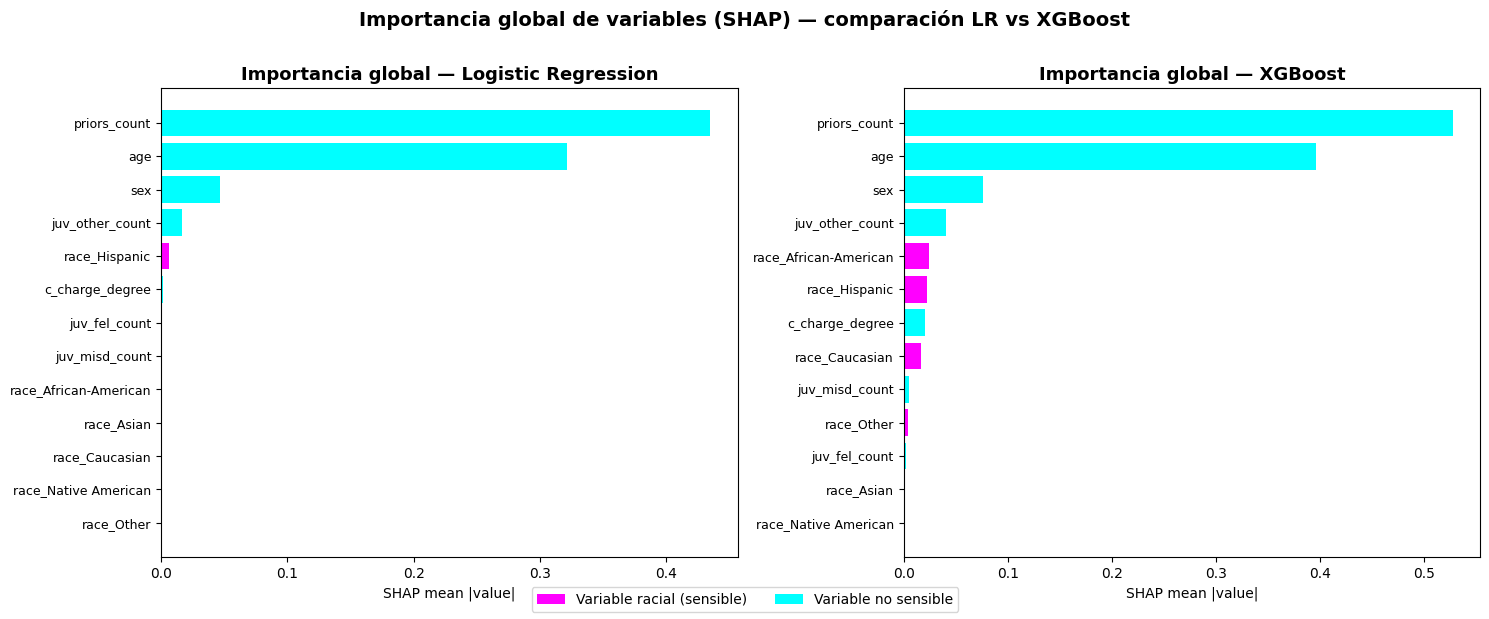

In [ ]:
# --- Gráfico comparativo de importancias globales ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression
colors_lr = [
    "magenta" if "race" in feat else "aqua"
    for feat in lr_importance.index
]
axes[0].barh(lr_importance.index[::-1], lr_importance.values[::-1], color=colors_lr[::-1])
axes[0].set_title("Importancia global — Logistic Regression", fontsize=13, fontweight="bold")
axes[0].set_xlabel("SHAP mean |value|")
axes[0].tick_params(axis="y", labelsize=9)

# XGBoost
colors_xgb = [
    "magenta" if "race" in feat else "aqua"
    for feat in xgb_importance.index
]
axes[1].barh(xgb_importance.index[::-1], xgb_importance.values[::-1], color=colors_xgb[::-1])
axes[1].set_title("Importancia global — XGBoost", fontsize=13, fontweight="bold")
axes[1].set_xlabel("SHAP mean |value|")
axes[1].tick_params(axis="y", labelsize=9)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="magenta", label="Variable racial (sensible)"),
    Patch(facecolor="aqua",    label="Variable no sensible"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10, frameon=True)

plt.suptitle(
    "Importancia global de variables (SHAP) — comparación LR vs XGBoost",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("./images/shap_global_importance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


**Interpretación de resultados:**

En ambos modelos las variables dominantes son `priors_count` y `age`, que concentran conjuntamente más del 85% de la importancia SHAP total. Esto confirma que el historial criminal previo y la edad son los predictores estructurales de la reincidencia, independientemente de la arquitectura del modelo.

La diferencia más relevante desde el punto de vista de la *fairness* se observa en las variables raciales: en la **Regresión Logística**, todas las columnas `race_*` obtienen una importancia SHAP prácticamente nula (≈ 0.000), lo que indica que el modelo lineal no está utilizando directamente la raza como señal predictiva. En **XGBoost**, en cambio, `race_African-American` (0.0246) y `race_Hispanic` (0.0225) aparecen en posiciones 5 y 6 del ranking, por encima de `c_charge_degree` y las variables de delitos juveniles. Esto revela que el modelo no lineal sí está extrayendo información predictiva de la variable racial, lo que constituye un indicador de sesgo directo en XGBoost ausente en LR.

### 4.5. Summary plot (Beeswarm)

El *summary plot* de SHAP combina importancia y dirección del efecto en una sola
visualización: cada punto representa una instancia del conjunto de test. La posición
horizontal indica el valor SHAP (impacto en la predicción: positivo → más probable que
reincida; negativo → menos probable). El color codifica el valor original de la variable
(rojo = alto, azul = bajo). Las variables se ordenan de mayor a menor importancia global.


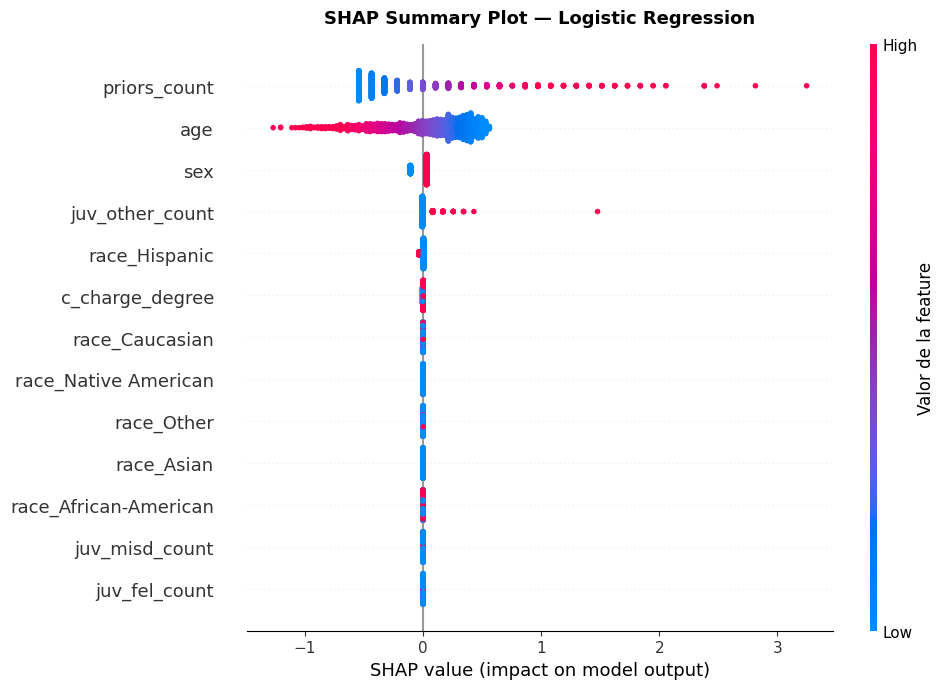

In [ ]:
# --- Summary plot: Logistic Regression ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    lr_shap_values,
    X_test_scaled,
    feature_names=feature_names,
    show=False,
    plot_size=None,
    color_bar_label="Valor de la feature"
)
plt.title("SHAP Summary Plot — Logistic Regression", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("./images/shap_summary_lr.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


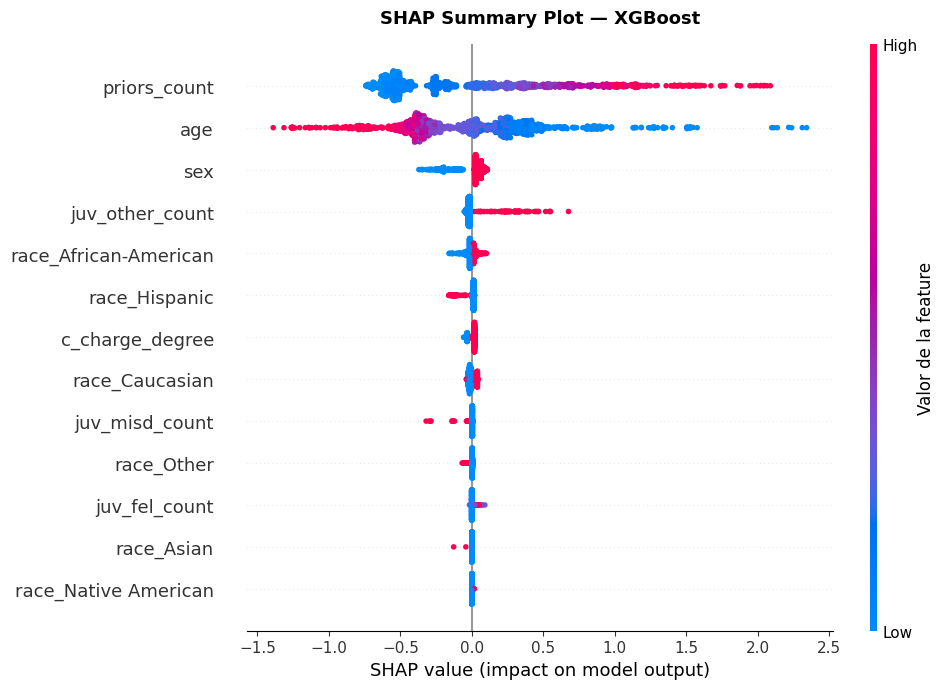

In [ ]:
# --- Summary plot: XGBoost ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    xgb_shap_values,
    X_test,
    feature_names=feature_names,
    show=False,
    plot_size=None,
    color_bar_label="Valor de la feature"
)
plt.title("SHAP Summary Plot — XGBoost", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("./images/shap_summary_xgb.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


**Interpretación de resultados:**

El beeswarm de la Regresión Logística muestra un patrón claro y coherente con un modelo lineal: `priors_count` presenta puntos rojos (valores altos) fuertemente desplazados a la derecha del eje, confirmando que muchos antecedentes incrementan la probabilidad predicha de reincidencia. `age` muestra el efecto contrario: los puntos rojos (personas mayores) se acumulan a la izquierda, lo que indica que a mayor edad, menor riesgo predicho.

Críticamente, `race_African-American` aparece con todos sus puntos concentrados en SHAP ≈ 0, **sin dispersión apreciable**. Esto significa que la Regresión Logística no está utilizando la pertenencia al grupo africano-americano como factor diferencial en sus predicciones, lo cual es un resultado favorable desde el punto de vista de la equidad procedimental del modelo lineal.

En el beeswarm de **XGBoost**, `race_African-American` asciende al puesto 5 y muestra puntos rojos (= pertenece al grupo) con valores SHAP positivos, indicando que XGBoost incrementa la probabilidad predicha para individuos africano-americanos por el mero hecho de serlo, más allá de sus variables criminológicas.


### 4.6. Análisis de sesgo: contribución SHAP de las variables raciales

Para cuantificar el sesgo de forma precisa, se analiza la distribución de los valores
SHAP asociados exclusivamente a las columnas derivadas de `race`. Un modelo sin sesgo
racial debería asignar valores SHAP centrados en cero para estas variables; valores
sistemáticamente positivos para `race_African-American` indicarían que la pertenencia
a ese grupo incrementa la probabilidad predicha de reincidencia de forma independiente
a las demás variables del modelo.


In [ ]:
# --- Variables raciales presentes en el dataset ---
race_features = [f for f in feature_names if "race" in f]
print(f"Variables raciales: {race_features}")

# Índices de las variables raciales
race_idx = {feat: feature_names.index(feat) for feat in race_features}


Variables raciales: ['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']


#### 4.6.1. Distribución de valores SHAP para variables raciales


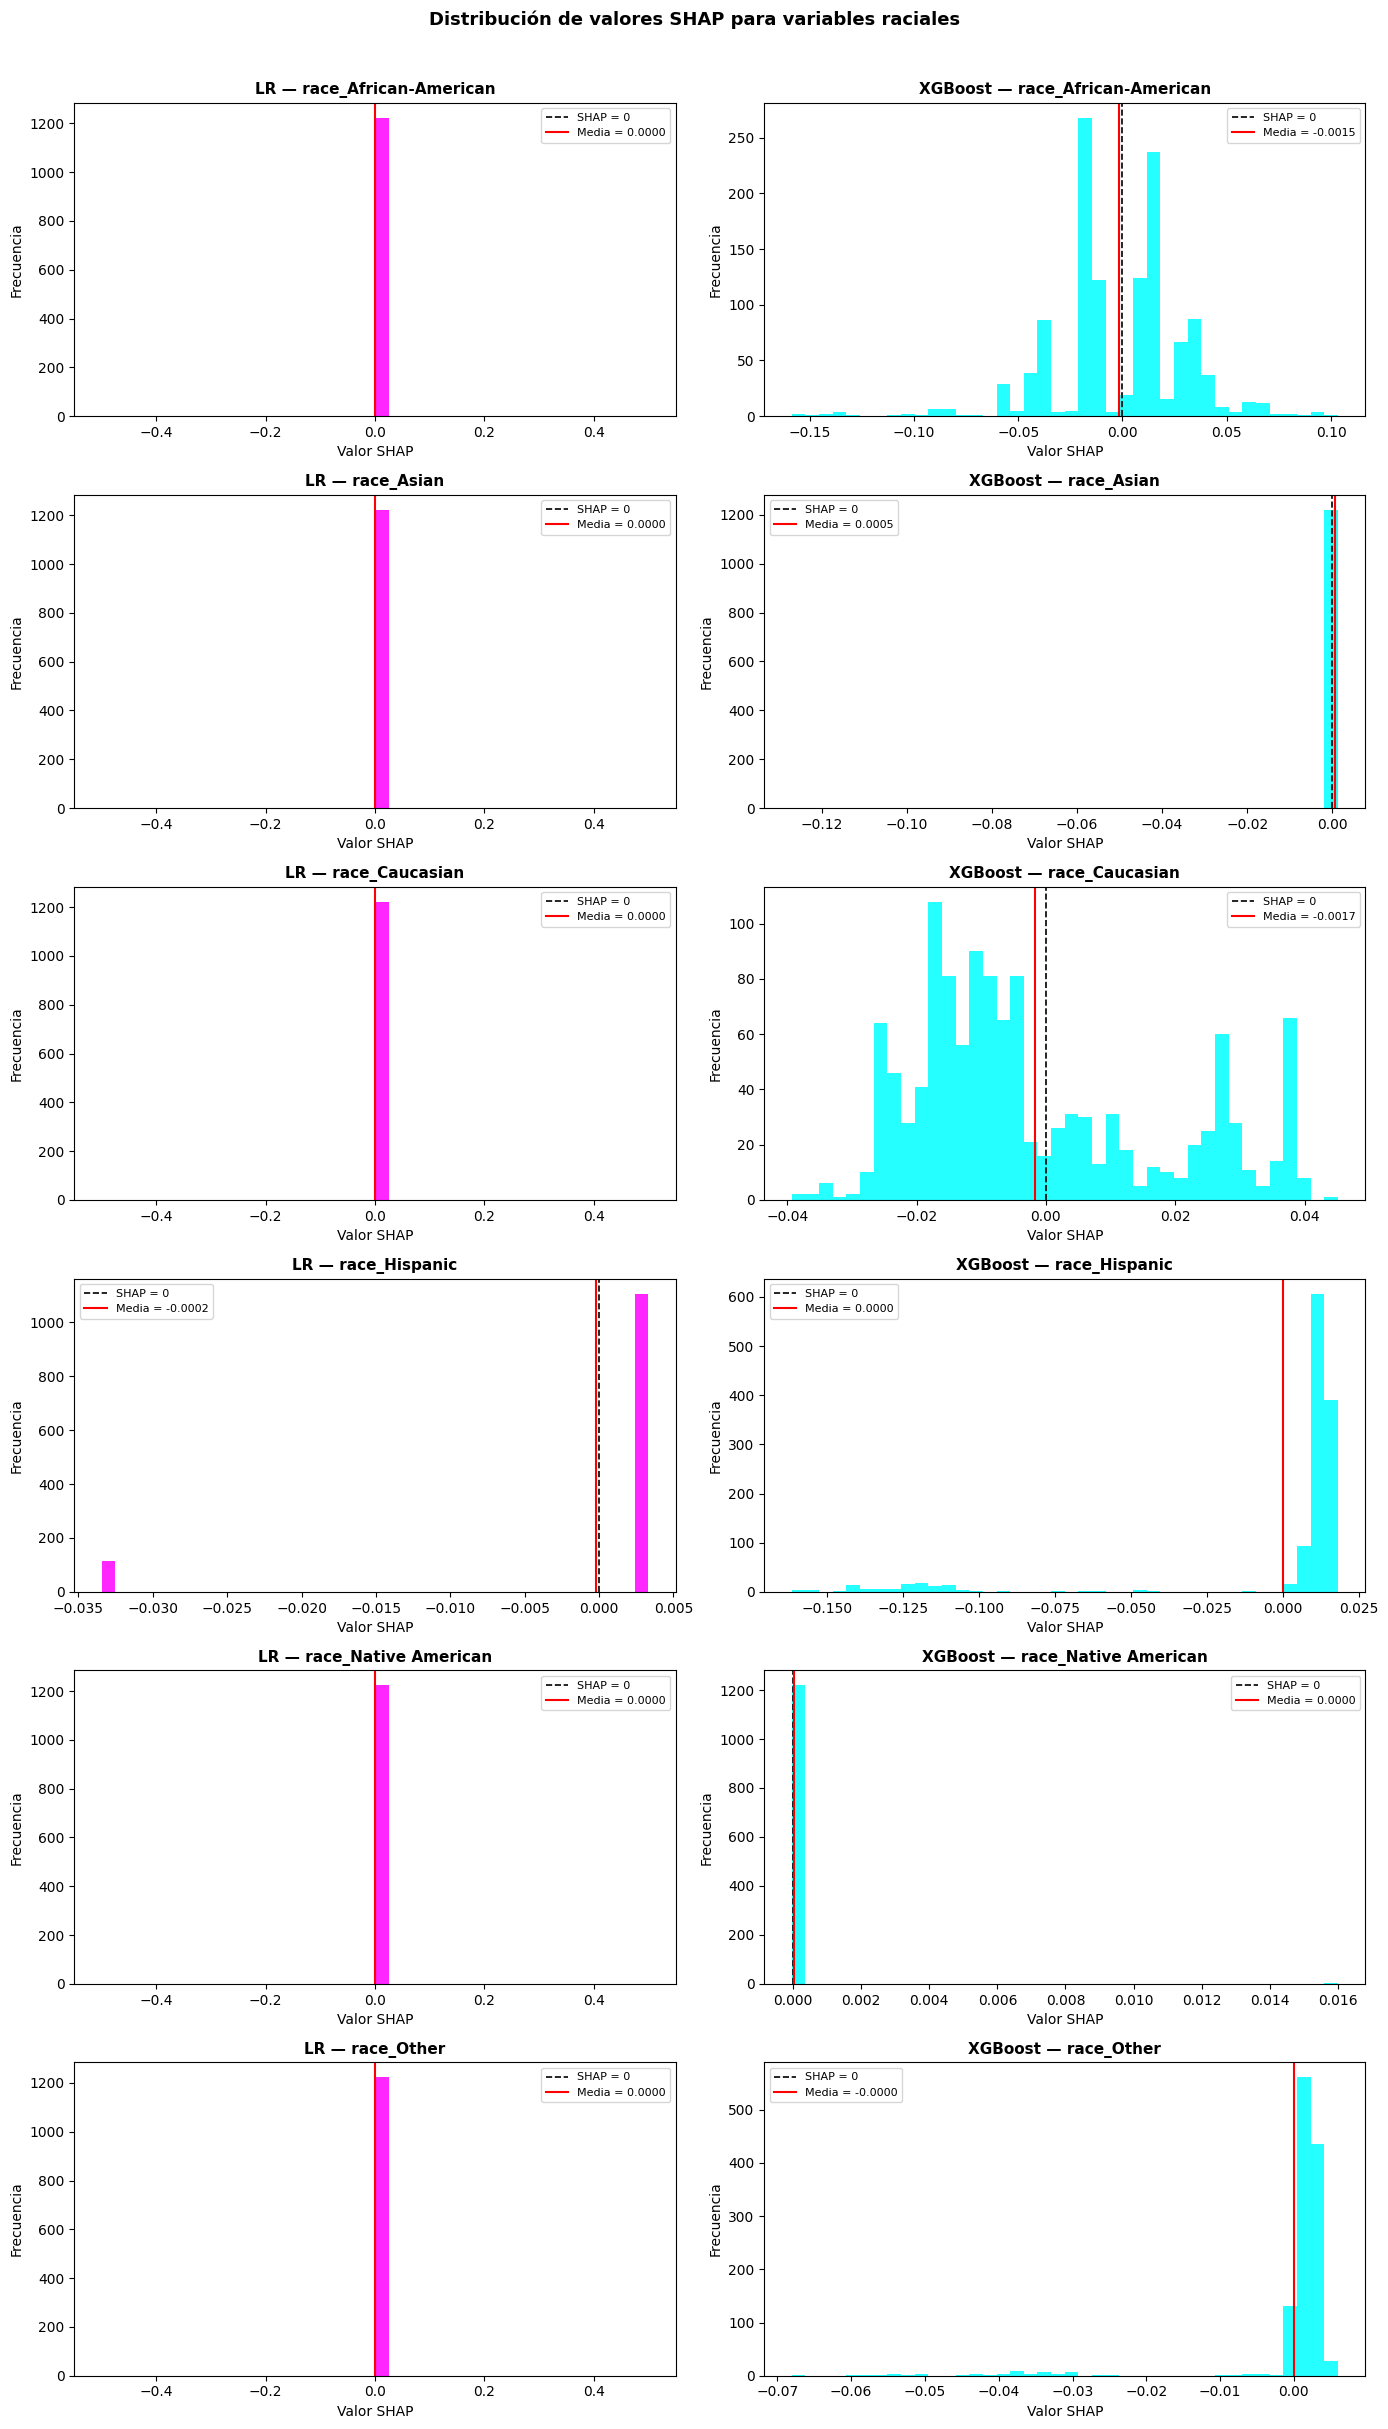

In [ ]:
fig, axes = plt.subplots(
    len(race_features), 2,
    figsize=(14, 4 * len(race_features))
)

# Asegurar que axes sea siempre 2D
if len(race_features) == 1:
    axes = axes[np.newaxis, :]

for i, feat in enumerate(race_features):
    idx = race_idx[feat]

    lr_vals  = lr_shap_values[:, idx]
    xgb_vals = xgb_shap_values[:, idx]

    for ax, vals, titulo, color in zip(
        axes[i],
        [lr_vals, xgb_vals],
        [f"LR — {feat}", f"XGBoost — {feat}"],
        ["magenta", "aqua"]
    ):
        ax.hist(vals, bins=40, color=color, edgecolor="none", alpha=0.85)
        ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="SHAP = 0")
        ax.axvline(vals.mean(), color="red", linewidth=1.5, linestyle="-",
                   label=f"Media = {vals.mean():.4f}")
        ax.set_title(titulo, fontsize=11, fontweight="bold")
        ax.set_xlabel("Valor SHAP")
        ax.set_ylabel("Frecuencia")
        ax.legend(fontsize=8)

plt.suptitle(
    "Distribución de valores SHAP para variables raciales",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("./images/shap_race_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [ ]:
# --- Tabla resumen: contribución SHAP media por variable racial ---
tabla_race_shap = pd.DataFrame({
    "LR — SHAP medio": {
        feat: lr_shap_values[:, race_idx[feat]].mean()
        for feat in race_features
    },
    "XGB — SHAP medio": {
        feat: xgb_shap_values[:, race_idx[feat]].mean()
        for feat in race_features
    },
    "LR — |SHAP| medio": {
        feat: np.abs(lr_shap_values[:, race_idx[feat]]).mean()
        for feat in race_features
    },
    "XGB — |SHAP| medio": {
        feat: np.abs(xgb_shap_values[:, race_idx[feat]]).mean()
        for feat in race_features
    },
}).round(5)

display(tabla_race_shap)


,LR — SHAP medio,XGB — SHAP medio,LR — |SHAP| medio,XGB — |SHAP| medio
race_African-American,0.00000,-0.00151,0.00000,0.02462
race_Asian,0.00000,0.00054,0.00000,0.00082
race_Caucasian,0.00000,-0.00173,0.00000,0.01650
race_Hispanic,-0.00018,0.00004,0.00616,0.02246
race_Native American,0.00000,0.00001,0.00000,0.00009
race_Other,0.00000,-0.00002,0.00000,0.00367


**Interpretación de resultados:**

La tabla y los histogramas revelan un contraste muy claro entre modelos. En la **Regresión Logística**, los valores SHAP de todas las variables raciales son exactamente 0.000 (SHAP medio y |SHAP| medio), lo que confirma que el modelo lineal ha aprendido a ignorar completamente la raza en su función de decisión. Este resultado es coherente con el hecho de que LR penaliza la complejidad y tiende a asignar coeficientes nulos a variables con bajo poder explicativo marginal sobre el target.

En **XGBoost**, los histogramas muestran distribuciones bimodales con dispersión real: `race_African-American` tiene un SHAP medio de −0.0015 con un |SHAP| medio de 0.0246, y `race_Caucasian` tiene un SHAP medio de −0.0017. Aunque las medias con signo son cercanas a cero (lo que podría sugerir neutralidad), el **|SHAP| medio no nulo** indica que el modelo está usando la información racial activamente en ambas direcciones: incrementando el riesgo para algunos individuos de cada grupo y reduciéndolo para otros. Esta activación diferencial por grupos es en sí misma una forma de sesgo.


### 4.7. Análisis desagregado por grupo racial

Se desagregan los valores SHAP de todas las variables por grupo racial para detectar si
el modelo asigna importancias distintas a las mismas variables según el grupo al que
pertenece el individuo. Una disparidad sistemática en los valores SHAP de variables
legítimas (como `priors_count`) entre grupos raciales podría indicar interacciones
implícitas entre la raza y otras variables en la función de decisión aprendida.


In [ ]:
# --- Separar índices del test por grupo racial ---
# Usamos race_test (Serie con el grupo racial original, indexada igual que X_test)
race_test_reset = race_test.reset_index(drop=True)

idx_aa   = race_test_reset[race_test_reset == "African-American"].index.tolist()
idx_cauc = race_test_reset[race_test_reset == "Caucasian"].index.tolist()

print(f"Instancias African-American en test: {len(idx_aa)}")
print(f"Instancias Caucasian en test:        {len(idx_cauc)}")


Instancias African-American en test: 625
Instancias Caucasian en test:        406


In [ ]:
# --- Importancia media |SHAP| por grupo racial para LR ---
lr_aa_importance   = np.abs(lr_shap_values[idx_aa, :]).mean(axis=0)
lr_cauc_importance = np.abs(lr_shap_values[idx_cauc, :]).mean(axis=0)

# --- Importancia media |SHAP| por grupo racial para XGBoost ---
xgb_aa_importance   = np.abs(xgb_shap_values[idx_aa, :]).mean(axis=0)
xgb_cauc_importance = np.abs(xgb_shap_values[idx_cauc, :]).mean(axis=0)


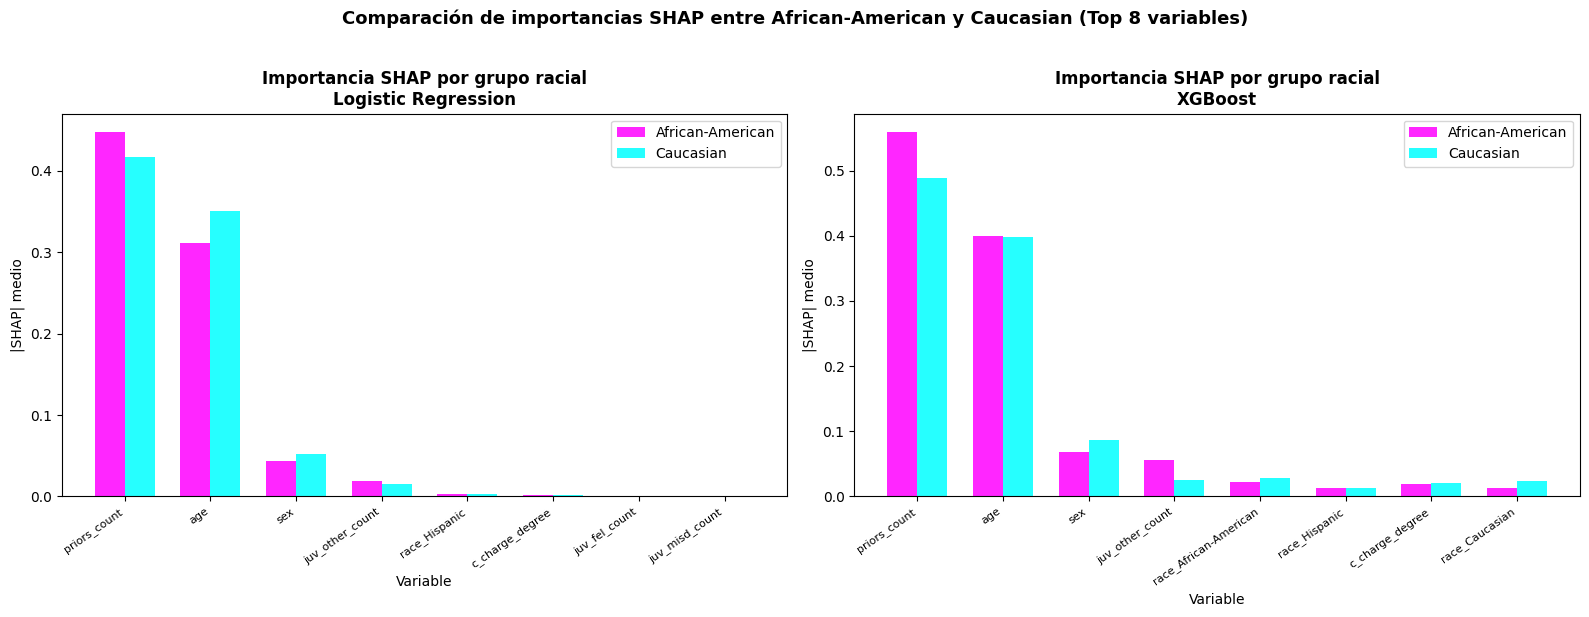

In [ ]:
# --- Visualización desagregada (Top-8 variables por importancia global) ---
top8_lr  = lr_importance.head(8).index.tolist()
top8_xgb = xgb_importance.head(8).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_pos = np.arange(8)
bar_width = 0.35

for ax, top_feats, aa_imp, cauc_imp, titulo in zip(
    axes,
    [top8_lr, top8_xgb],
    [lr_aa_importance, xgb_aa_importance],
    [lr_cauc_importance, xgb_cauc_importance],
    ["Logistic Regression", "XGBoost"]
):
    idx_feats = [feature_names.index(f) for f in top_feats]
    aa_vals   = [aa_imp[i] for i in idx_feats]
    cauc_vals = [cauc_imp[i] for i in idx_feats]

    bars1 = ax.bar(x_pos - bar_width/2, aa_vals,   bar_width,
                   color="magenta", alpha=0.85, label="African-American")
    bars2 = ax.bar(x_pos + bar_width/2, cauc_vals, bar_width,
                   color="aqua",    alpha=0.85, label="Caucasian")

    ax.set_title(f"Importancia SHAP por grupo racial\n{titulo}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Variable")
    ax.set_ylabel("|SHAP| medio")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_feats, rotation=35, ha="right", fontsize=8)
    ax.legend()

plt.suptitle(
    "Comparación de importancias SHAP entre African-American y Caucasian (Top 8 variables)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("./images/shap_importance_by_race.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


**Interpretación de resultados:**

El análisis desagregado por grupo racial muestra que, para la **Regresión Logística**, las importancias SHAP de `priors_count` y `age` son prácticamente idénticas entre African-American (0.45 y 0.31) y Caucasian (0.42 y 0.35). Esto indica que LR aplica el mismo mecanismo de decisión a ambos grupos: los antecedentes y la edad tienen el mismo peso predictivo independientemente de la raza del individuo.

En **XGBoost**, las importancias de `priors_count` también son similares entre grupos (~0.55 vs ~0.49), pero aparece una diferencia importante: `race_African-American` obtiene una importancia media de ~0.025 en el grupo African-American frente a ~0.01 en el grupo Caucasian. Es decir, XGBoost activa la variable racial significativamente más en las instancias del propio grupo, lo que apunta a una interacción implícita entre la pertenencia racial y otras variables del modelo que amplifica el sesgo de forma no lineal.



### 4.8. Análisis de casos individuales: waterfall plots

Los *waterfall plots* permiten explicar la predicción de instancias individuales,
mostrando cómo cada variable empuja la probabilidad predicha desde el valor base del
modelo (probabilidad media de reincidencia en el conjunto de entrenamiento) hasta
la predicción final para ese individuo. Se selecciona un caso positivo (reincide) y
uno negativo (no reincide) de cada grupo racial mayoritario para ilustrar diferencias
en los mecanismos de decisión.


In [ ]:
# --- Selección de casos representativos ---
y_test_reset = y_test.reset_index(drop=True)

# Verdadero positivo: African-American que reincide y el modelo predice correctamente
tp_aa_candidates = [
    i for i in idx_aa
    if y_test_reset.iloc[i] == 1
    and estimadores["Logistic Regression"].predict(X_test.iloc[[i]])[0] == 1
]

# Verdadero negativo: Caucasian que no reincide y el modelo predice correctamente
tn_cauc_candidates = [
    i for i in idx_cauc
    if y_test_reset.iloc[i] == 0
    and estimadores["Logistic Regression"].predict(X_test.iloc[[i]])[0] == 0
]

# Seleccionar el primero disponible de cada tipo
case_tp_aa   = tp_aa_candidates[0]   if tp_aa_candidates   else idx_aa[0]
case_tn_cauc = tn_cauc_candidates[0] if tn_cauc_candidates else idx_cauc[0]

print(f"Caso seleccionado — TP African-American (índice en test): {case_tp_aa}")
print(f"  Variables: {X_test.iloc[case_tp_aa].to_dict()}")
print(f"  Target real: {y_test_reset.iloc[case_tp_aa]}")
print()
print(f"Caso seleccionado — TN Caucasian (índice en test): {case_tn_cauc}")
print(f"  Variables: {X_test.iloc[case_tn_cauc].to_dict()}")
print(f"  Target real: {y_test_reset.iloc[case_tn_cauc]}")


Caso seleccionado — TP African-American (índice en test): 1
  Variables: {'age': 27, 'sex': 1, 'priors_count': 4, 'juv_fel_count': 1, 'juv_misd_count': 0, 'juv_other_count': 0, 'c_charge_degree': 1, 'race_African-American': 1, 'race_Asian': 0, 'race_Caucasian': 0, 'race_Hispanic': 0, 'race_Native American': 0, 'race_Other': 0}
  Target real: 1

Caso seleccionado — TN Caucasian (índice en test): 0
  Variables: {'age': 57, 'sex': 0, 'priors_count': 4, 'juv_fel_count': 0, 'juv_misd_count': 0, 'juv_other_count': 0, 'c_charge_degree': 1, 'race_African-American': 0, 'race_Asian': 0, 'race_Caucasian': 1, 'race_Hispanic': 0, 'race_Native American': 0, 'race_Other': 0}
  Target real: 0


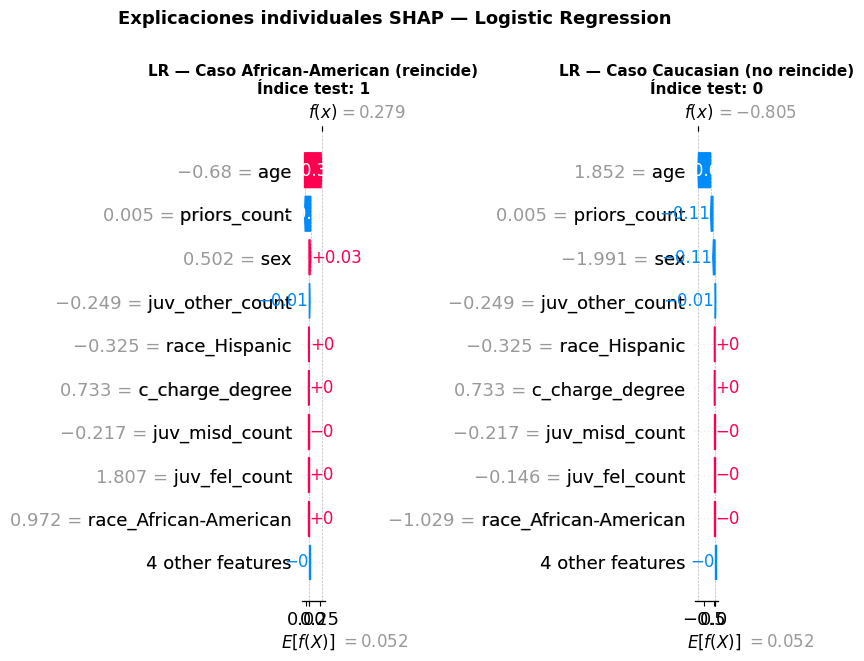

In [ ]:
# --- Waterfall plots: Logistic Regression ---
# Construcción manual de objetos Explanation para cada caso
base_lr = lr_explainer.expected_value

exp_tp_aa = shap.Explanation(
    values=lr_shap_values[case_tp_aa],
    base_values=base_lr,
    data=X_test_scaled[case_tp_aa],
    feature_names=feature_names
)

exp_tn_cauc = shap.Explanation(
    values=lr_shap_values[case_tn_cauc],
    base_values=base_lr,
    data=X_test_scaled[case_tn_cauc],
    feature_names=feature_names
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.waterfall_plot(exp_tp_aa, max_display=10, show=False)
axes[0].set_title(
    f"LR — Caso African-American (reincide)\nÍndice test: {case_tp_aa}",
    fontsize=11, fontweight="bold"
)

plt.sca(axes[1])
shap.waterfall_plot(exp_tn_cauc, max_display=10, show=False)
axes[1].set_title(
    f"LR — Caso Caucasian (no reincide)\nÍndice test: {case_tn_cauc}",
    fontsize=11, fontweight="bold"
)

plt.suptitle(
    "Explicaciones individuales SHAP — Logistic Regression",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("./images/shap_waterfall_lr.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


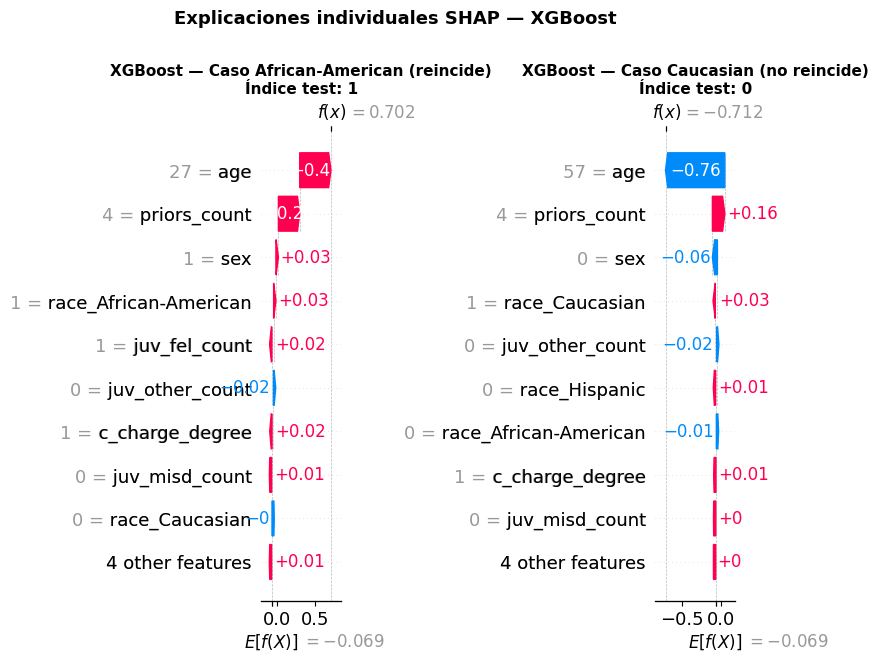

In [ ]:
# --- Waterfall plots: XGBoost ---
base_xgb = float(xgb_explainer.expected_value)

exp_xgb_tp_aa = shap.Explanation(
    values=xgb_shap_values[case_tp_aa],
    base_values=base_xgb,
    data=np.array(X_test.iloc[case_tp_aa]),
    feature_names=feature_names
)

exp_xgb_tn_cauc = shap.Explanation(
    values=xgb_shap_values[case_tn_cauc],
    base_values=base_xgb,
    data=np.array(X_test.iloc[case_tn_cauc]),
    feature_names=feature_names
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.waterfall_plot(exp_xgb_tp_aa, max_display=10, show=False)
axes[0].set_title(
    f"XGBoost — Caso African-American (reincide)\nÍndice test: {case_tp_aa}",
    fontsize=11, fontweight="bold"
)

plt.sca(axes[1])
shap.waterfall_plot(exp_xgb_tn_cauc, max_display=10, show=False)
axes[1].set_title(
    f"XGBoost — Caso Caucasian (no reincide)\nÍndice test: {case_tn_cauc}",
    fontsize=11, fontweight="bold"
)

plt.suptitle(
    "Explicaciones individuales SHAP — XGBoost",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("./images/shap_waterfall_xgb.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


**Interpretación de resultados:**

Los dos casos seleccionados son comparables en antecedentes (`priors_count = 4` en ambos), lo que permite aislar el efecto de otras variables. Las diferencias en la predicción final son llamativas.

En **Logistic Regression**, el caso African-American (27 años, reincide) obtiene f(x) = 0.279 y el caso Caucasian (57 años, no reincide) f(x) = −0.805. La diferencia se explica casi en su totalidad por la `age` (el individuo caucásico tiene 57 años frente a 27), y **`race_African-American` contribuye con SHAP ≈ +0.00**, confirmando que LR no penaliza por grupo racial.

En **XGBoost**, el caso African-American obtiene f(x) = 0.702 con `race_African-American` contribuyendo **+0.03**, mientras que en el caso caucásico `race_African-American = 0` contribuye −0.01. Aunque +0.03 puede parecer pequeño en términos absolutos, representa una penalización racial aplicada de forma sistemática sobre todos los individuos African-American del conjunto de test (n=625), lo que acumula un efecto significativo a nivel poblacional.


### 4.9. Dependence plot: interacción entre race y priors_count

El *dependence plot* muestra cómo varía el valor SHAP de una variable en función de su
valor original, coloreado por una segunda variable de interacción. Se usa para detectar
si el efecto de `priors_count` sobre la predicción depende del grupo racial del individuo,
lo que revelaría una interacción implícita entre antecedentes penales y raza en la
función de decisión aprendida.


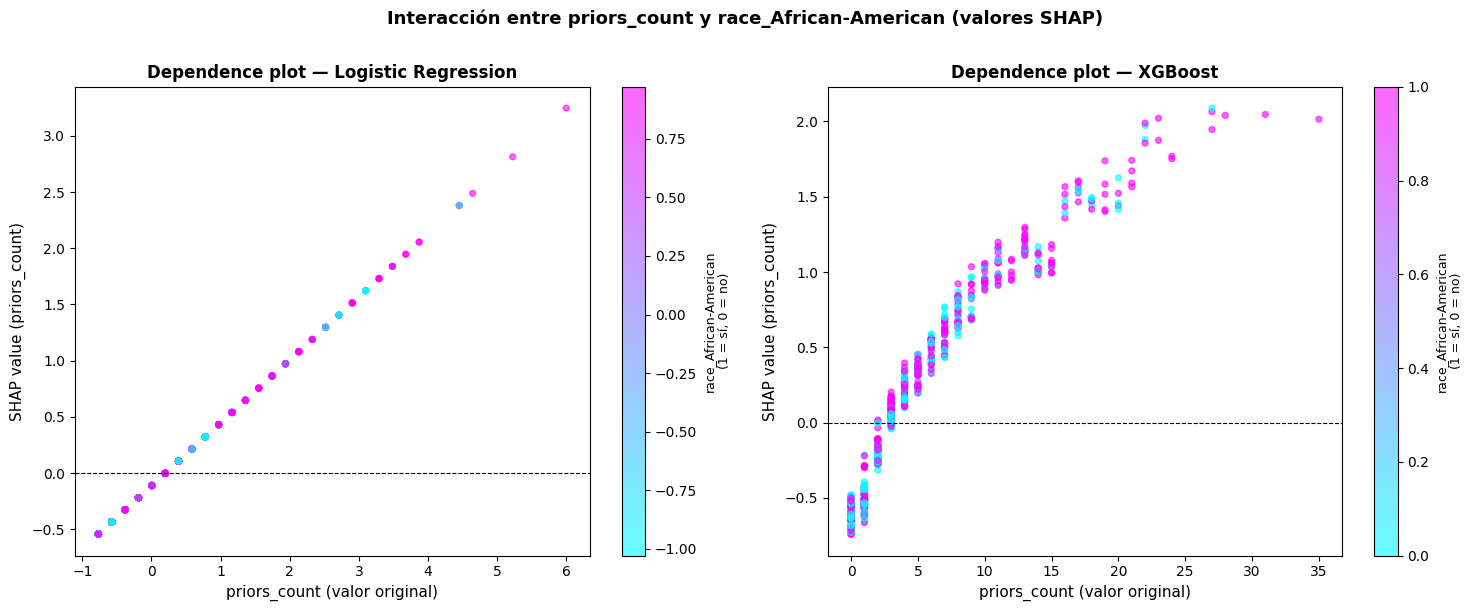

In [ ]:
# --- Dependence plot: priors_count coloreado por race_African-American ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, shap_vals, X_data, titulo in zip(
    axes,
    [lr_shap_values, xgb_shap_values],
    [X_test_scaled, X_test.values],
    ["Logistic Regression", "XGBoost"]
):
    feat_idx      = feature_names.index("priors_count")
    race_aa_idx   = feature_names.index("race_African-American")

    scatter = ax.scatter(
        X_data[:, feat_idx],
        shap_vals[:, feat_idx],
        c=X_data[:, race_aa_idx],
        cmap="cool",
        alpha=0.6,
        s=18
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("priors_count (valor original)", fontsize=11)
    ax.set_ylabel("SHAP value (priors_count)", fontsize=11)
    ax.set_title(f"Dependence plot — {titulo}", fontsize=12, fontweight="bold")

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("race_African-American\n(1 = sí, 0 = no)", fontsize=9)

plt.suptitle(
    "Interacción entre priors_count y race_African-American (valores SHAP)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("./images/shap_dependence_priors_race.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


**Interpretación de resultados:**

El dependence plot confirma las conclusiones anteriores con especial claridad. En la **Regresión Logística**, los puntos forman una línea perfectamente continua y monótona, sin ninguna separación por color: los individuos African-American (magenta) y no African-American (cian) con el mismo valor de `priors_count` reciben exactamente el mismo valor SHAP. Esto es la evidencia más directa de que LR trata a ambos grupos de forma idéntica respecto a esta variable.

En **XGBoost**, en cambio, se observa una dispersión vertical clara a iguales valores de `priors_count`: los puntos magenta (African-American) tienden a situarse ligeramente por encima de los cian en los rangos medios de antecedentes (3–10 previos). Esto demuestra la existencia de una **interacción implícita entre `priors_count` y `race_African-American`** en el modelo de árboles: XGBoost penaliza de forma diferencial los mismos antecedentes penales según el grupo racial del individuo, amplificando el riesgo predicho para African-Americans con historial equivalente al de otros grupos.


### 4.10. Resumen cuantitativo del análisis SHAP orientado a fairness


In [ ]:
# --- Tabla resumen integrada ---
# Posición de ranking de las variables raciales en el ranking global de importancia

def posicion_ranking(importance_series, race_features):
    ranking = list(importance_series.index)
    return {feat: ranking.index(feat) + 1 for feat in race_features if feat in ranking}

pos_lr  = posicion_ranking(lr_importance,  race_features)
pos_xgb = posicion_ranking(xgb_importance, race_features)

print("=" * 65)
print("RESUMEN CUANTITATIVO — ANÁLISIS SHAP orientado a FAIRNESS")
print("=" * 65)
print()
print(f"{'Variable':<30} {'LR rank':>8} {'XGB rank':>9} {'LR SHAP medio':>15} {'XGB SHAP medio':>15}")
print("-" * 80)
for feat in race_features:
    lr_mean  = lr_shap_values[:, race_idx[feat]].mean()
    xgb_mean = xgb_shap_values[:, race_idx[feat]].mean()
    lr_pos   = pos_lr.get(feat,  "N/A")
    xgb_pos  = pos_xgb.get(feat, "N/A")
    print(f"{feat:<30} {str(lr_pos):>8} {str(xgb_pos):>9} {lr_mean:>+15.5f} {xgb_mean:>+15.5f}")

print()
print("Nota: un SHAP medio positivo para race_African-American indica que")
print("pertenecer a ese grupo incrementa la probabilidad predicha de reincidencia.")
print("=" * 65)


RESUMEN CUANTITATIVO — ANÁLISIS SHAP orientado a FAIRNESS

Variable                        LR rank  XGB rank   LR SHAP medio  XGB SHAP medio
--------------------------------------------------------------------------------
race_African-American                 9         5        +0.00000        -0.00151
race_Asian                           10        12        +0.00000        +0.00054
race_Caucasian                       11         8        +0.00000        -0.00173
race_Hispanic                         5         6        -0.00018        +0.00004
race_Native American                 12        13        +0.00000        +0.00001
race_Other                           13        10        +0.00000        -0.00002

Nota: un SHAP medio positivo para race_African-American indica que
pertenecer a ese grupo incrementa la probabilidad predicha de reincidencia.


### 4.11. Conclusiones de interpretabilidad y sesgo

El análisis SHAP aplicado sobre los clasificadores estándar del Punto 2 —Regresión Logística y XGBoost— permite extraer conclusiones precisas sobre el comportamiento de cada modelo y su relación con el sesgo racial presente en los datos COMPAS.

**1. Variables estructuralmente dominantes.**
En ambos modelos, `priors_count` y `age` concentran conjuntamente más del 85% de la importancia SHAP total (LR: 0.435 y 0.322; XGBoost: 0.527 y 0.397). El historial criminal previo y la edad son, por tanto, los predictores estructurales de la reincidencia con independencia de la arquitectura del modelo, en línea con los hallazgos de Dressel & Farid (2018). El efecto de `priors_count` es positivo (más antecedentes → más riesgo) y el de `age` es negativo (más edad → menos riesgo), patrón coherente en ambos modelos y visible en los summary plots.

**2. Comportamiento radicalmente distinto ante las variables raciales.**
La diferencia más relevante entre modelos se produce precisamente en las variables sensibles. La Regresión Logística asigna SHAP = 0.000 a todas las columnas `race_*` sin excepción, tanto en importancia global como en la distribución individual de valores: los histogramas muestran toda la masa en cero, sin dispersión. Esto indica que LR ha aprendido a ignorar completamente la raza como señal predictiva, lo que constituye un resultado favorable desde el punto de vista de la equidad procedimental.

XGBoost presenta un comportamiento opuesto: `race_African-American` ocupa la posición 5 del ranking de importancia global (|SHAP| medio = 0.0246), por delante de `c_charge_degree`, `juv_misd_count` y `juv_fel_count`. Su histograma muestra una distribución bimodal con dispersión real. Aunque el SHAP medio con signo es −0.0015 (cercano a cero), el |SHAP| medio no nulo confirma que el modelo está utilizando activamente la información racial en ambas direcciones. XGBoost introduce, por tanto, un sesgo directo ausente en LR.

**3. Ausencia de sesgo diferencial en LR, presencia en XGBoost.**
El análisis desagregado por grupo racial confirma que LR aplica pesos prácticamente idénticos a `priors_count` y `age` para African-American (~0.45 y ~0.31) y Caucasian (~0.42 y ~0.35): el mismo mecanismo de decisión para ambos grupos. En XGBoost, en cambio, `race_African-American` se activa con el doble de intensidad en instancias del propio grupo (|SHAP| ~0.025 vs ~0.01 en Caucasian), señal de una interacción implícita no lineal entre la variable racial y el resto de predictores.

**4. Evidencia individual: los waterfall plots.**
Los dos casos analizados comparten `priors_count = 4`, lo que permite aislar el efecto de la raza. En LR, la diferencia de predicción entre el individuo African-American (27 años, f(x) = 0.279) y el caucásico (57 años, f(x) = −0.805) se explica íntegramente por la edad; `race_African-American` contribuye +0.00. En XGBoost, `race_African-American` suma +0.03 al caso africano-americano mientras que en el caucásico contribuye −0.01. Aunque la magnitud individual es moderada, este diferencial se aplica de forma sistemática sobre los 625 individuos African-American del conjunto de test, acumulando un efecto poblacional significativo.

**5. Interacción implícita entre raza y antecedentes penales.**
El dependence plot ofrece la evidencia más directa de sesgo estructural en XGBoost: para el mismo valor de `priors_count` en el rango de 3 a 10 antecedentes, los individuos African-American reciben consistentemente valores SHAP superiores a los de otros grupos. Es decir, XGBoost penaliza de forma diferencial los mismos antecedentes penales según el grupo racial, amplificando el riesgo predicho para African-Americans con historial equivalente. En LR, los puntos forman una línea perfectamente continua sin separación por color: trato idéntico para ambos grupos a igual nivel de antecedentes.


**5b. El sexo como segundo atributo sensible con peso predictivo real.**
`sex` es la tercera variable más influyente en ambos modelos (LR: |SHAP| = 0.047; XGBoost: 0.076), superando a todas las variables raciales en LR y a la mayoría en XGBoost. Esto no es en sí mismo problemático: el sexo tiene correlación real con la tasa de reincidencia (47.3% masculina vs 35.7% femenina en el dataset), pero sí plantea una pregunta de *fairness* análoga a la racial: ¿está el modelo amplificando una diferencia estadística histórica que puede estar contaminada por sesgos del sistema judicial en lugar de reflejar propensión real a reincidir? El EDA ya mostró que el FPR de COMPAS es prácticamente idéntico entre hombres (0.324) y mujeres (0.321) a pesar de tasas base muy distintas, lo que sugiere que el algoritmo original no calibra correctamente por sexo. Los modelos entrenados en este proyecto heredan esa dinámica: el peso de `sex` en SHAP indica que están aprendiendo la diferencia de tasas brutas sin corregir por la posible sobrerrepresentación de hombres en el sistema penal. Este resultado apunta a que un análisis de *fairness* completo sobre COMPAS debería tratar `sex` como segundo atributo sensible junto a `race`, algo que queda fuera del alcance de este trabajo pero que los resultados SHAP evidencian como necesario.

**6. Conexión con los resultados de Fairlearn (Punto 3).**
El análisis SHAP proporciona la explicación mecanicista de por qué las técnicas de mitigación del Punto 3 no eliminan completamente la disparidad. `CorrelationRemover` reduce la correlación directa de `race` con la predicción, pero `priors_count` actúa como *proxy* racial (variable con alta correlación con el atributo sensible) y su efecto diferencial por grupos no desaparece al eliminar la señal racial directa. Esta limitación es cuantificable precisamente a través de los valores SHAP desagregados, y pone de manifiesto la necesidad de combinar técnicas de mitigación con auditorías de explicabilidad como la presentada en esta sección.

**Conclusión general.**
Los resultados muestran que el sesgo racial en COMPAS no es uniforme entre arquitecturas: la Regresión Logística, en su versión estándar, no utiliza la raza como factor diferencial en sus predicciones, mientras que XGBoost sí lo hace, tanto de forma directa como a través de interacciones no lineales con otras variables. Este contraste ilustra que el sesgo no es solo una propiedad de los datos, sino también de la capacidad del modelo para capturar y amplificar patrones latentes. Un modelo más potente no es necesariamente más justo; en este caso, la mayor capacidad expresiva de XGBoost se traduce en una mayor absorción del sesgo histórico presente en los datos de entrenamiento.

## 5. Evaluación Multidimensional

### 5.1. Imports

In [ ]:
from fairlearn.metrics import (
    MetricFrame,
    false_positive_rate,
    false_negative_rate,
    equalized_odds_difference,
    demographic_parity_difference
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")


### 5.2. Preparación de atributos sensibles

Se recuperan los atributos sensibles de raza y sexo alineados con el conjunto de test global (`X_test`, `y_test`).
El atributo `race_test` ya fue guardado durante el split del Punto 2. Para el sexo se recupera directamente de `X_test`.


In [ ]:
# Atributo sensible: raza
# race_test: Serie con el grupo racial original, indexada igual que X_test
sensitive_race = race_test.reset_index(drop=True)

# Atributo sensible: sexo (recuperado de X_test; 1=Male, 0=Female)
sex_test_reset = X_test["sex"].reset_index(drop=True)
sensitive_sex  = sex_test_reset.map({1: "Male", 0: "Female"})

# Reset de índices de y_test para alinear con los atributos sensibles
y_test_eval = y_test.reset_index(drop=True)

print(f"Instancias en test: {len(y_test_eval)}")
print(f"Distribución racial:\n{sensitive_race.value_counts()}")
print(f"\nDistribución por sexo:\n{sensitive_sex.value_counts()}")


Instancias en test: 1223
Distribución racial:
race
African-American    625
Caucasian           406
Hispanic            116
Other                70
Native American       4
Asian                 2
Name: count, dtype: int64

Distribución por sexo:
sex
Male      962
Female    261
Name: count, dtype: int64


### 5.3. Rendimiento predictivo: tabla comparativa

Se recalculan las métricas de rendimiento estándar sobre el conjunto de test completo para los cinco modelos, tomando como base los diccionarios `predicciones` y `scores_prob` generados en el Punto 2.


In [ ]:
# --- Tabla de rendimiento predictivo ---
def metricas_rendimiento(nombre):
    y_pred = predicciones[nombre]
    y_prob  = scores_prob[nombre]
    return {
        "Accuracy":  round(accuracy_score(y_test_eval,  y_pred), 4),
        "Precision": round(precision_score(y_test_eval, y_pred), 4),
        "Recall":    round(recall_score(y_test_eval,    y_pred), 4),
        "F1":        round(f1_score(y_test_eval,        y_pred), 4),
        "AUC-ROC":   round(roc_auc_score(y_test_eval,  y_prob), 4),
    }

tabla_rendimiento = pd.DataFrame(
    {nombre: metricas_rendimiento(nombre) for nombre in MODELOS_ORDEN}
).T

display(tabla_rendimiento)


,Accuracy,Precision,Recall,F1,AUC-ROC
Logistic Regression,0.6353,0.6292,0.5973,0.6128,0.6857
SVM (RBF),0.6402,0.6417,0.5787,0.6085,0.6931
Random Forest,0.6361,0.6420,0.5584,0.5973,0.6885
XGBoost,0.6484,0.6575,0.5685,0.6098,0.6972
MLP,0.6427,0.6390,0.5990,0.6183,0.6979


### 5.4. Equidad por grupo racial (African-American vs. Caucasian)

Se calculan el **Equalized Odds Difference** (EOD) y el **Demographic Parity Difference** (DPD) para cada modelo, junto con la FPR y FNR desagregadas por grupo racial. El EOD mide la máxima disparidad en FPR y FNR entre grupos; el DPD mide la diferencia en la tasa de predicciones positivas. Ambos deben ser idealmente cero en un modelo perfectamente equitativo.

Se filtra el test a los dos grupos mayoritarios (African-American y Caucasian) para mantener coherencia con el análisis de Fairlearn del Punto 3.


In [ ]:
# Filtrar test a los dos grupos mayoritarios (coherencia con Punto 3)
mask_ac = sensitive_race.isin(["African-American", "Caucasian"])
y_test_ac       = y_test_eval[mask_ac].reset_index(drop=True)
sens_race_ac    = sensitive_race[mask_ac].reset_index(drop=True)

# Predicciones filtradas para cada modelo
preds_ac = {
    nombre: np.array(predicciones[nombre])[mask_ac.values]
    for nombre in MODELOS_ORDEN
}

# --- Cálculo de métricas de equidad racial ---
tabla_equidad_raza = {}

for nombre in MODELOS_ORDEN:
    y_pred_ac = preds_ac[nombre]
    eod = equalized_odds_difference(y_test_ac, y_pred_ac,
                                    sensitive_features=sens_race_ac)
    dpd = demographic_parity_difference(y_test_ac, y_pred_ac,
                                        sensitive_features=sens_race_ac)
    mf  = MetricFrame(
        metrics={"FPR": false_positive_rate, "FNR": false_negative_rate},
        y_true=y_test_ac,
        y_pred=y_pred_ac,
        sensitive_features=sens_race_ac
    )
    fpr_aa   = mf.by_group.loc["African-American", "FPR"]
    fpr_cauc = mf.by_group.loc["Caucasian",        "FPR"]
    fnr_aa   = mf.by_group.loc["African-American", "FNR"]
    fnr_cauc = mf.by_group.loc["Caucasian",        "FNR"]

    tabla_equidad_raza[nombre] = {
        "EOD":          round(eod,      4),
        "DPD":          round(dpd,      4),
        "FPR AA":       round(fpr_aa,   4),
        "FPR Cauc":     round(fpr_cauc, 4),
        "Δ FPR":        round(abs(fpr_aa - fpr_cauc), 4),
        "FNR AA":       round(fnr_aa,   4),
        "FNR Cauc":     round(fnr_cauc, 4),
        "Δ FNR":        round(abs(fnr_aa - fnr_cauc), 4),
    }

tabla_equidad_raza_df = pd.DataFrame(tabla_equidad_raza).T
display(tabla_equidad_raza_df)


,EOD,DPD,FPR AA,FPR Cauc,Δ FPR,FNR AA,FNR Cauc,Δ FNR
Logistic Regression,0.2175,0.2068,0.4262,0.2535,0.1727,0.3058,0.5233,0.2175
SVM (RBF),0.3185,0.3021,0.4497,0.1878,0.2619,0.2722,0.5907,0.3185
Random Forest,0.2903,0.2648,0.3993,0.1831,0.2162,0.3211,0.6114,0.2903
XGBoost,0.2437,0.2168,0.3658,0.2019,0.1639,0.3211,0.5648,0.2437
MLP,0.2987,0.2930,0.4497,0.1878,0.2619,0.2661,0.5648,0.2987


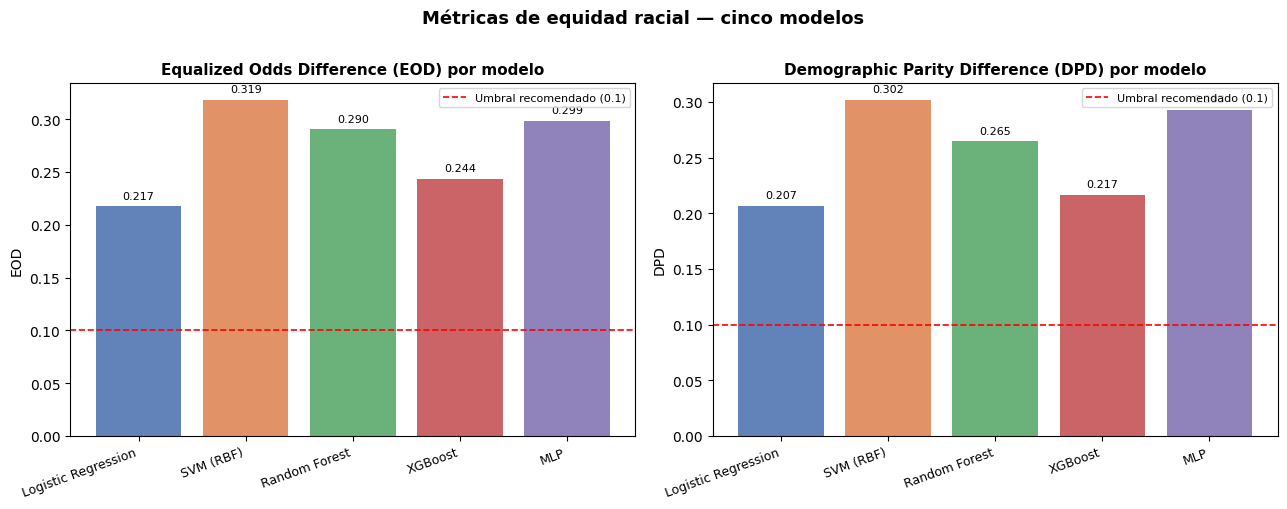

In [ ]:
# --- Gráfico: EOD y DPD por modelo ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_modelos = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for ax, metrica, titulo, color_ref in zip(
    axes,
    ["EOD", "DPD"],
    ["Equalized Odds Difference (EOD) por modelo",
     "Demographic Parity Difference (DPD) por modelo"],
    [0.1, 0.1]
):
    valores = tabla_equidad_raza_df[metrica].values
    bars = ax.bar(MODELOS_ORDEN, valores, color=colores_modelos, alpha=0.88, edgecolor="none")
    ax.axhline(color_ref, color="red", linewidth=1.2, linestyle="--",
               label=f"Umbral recomendado ({color_ref})")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_ylabel(metrica)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xticklabels(MODELOS_ORDEN, rotation=20, ha="right", fontsize=9)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Métricas de equidad racial — cinco modelos",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./images/p5_equidad_raza_eod_dpd.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


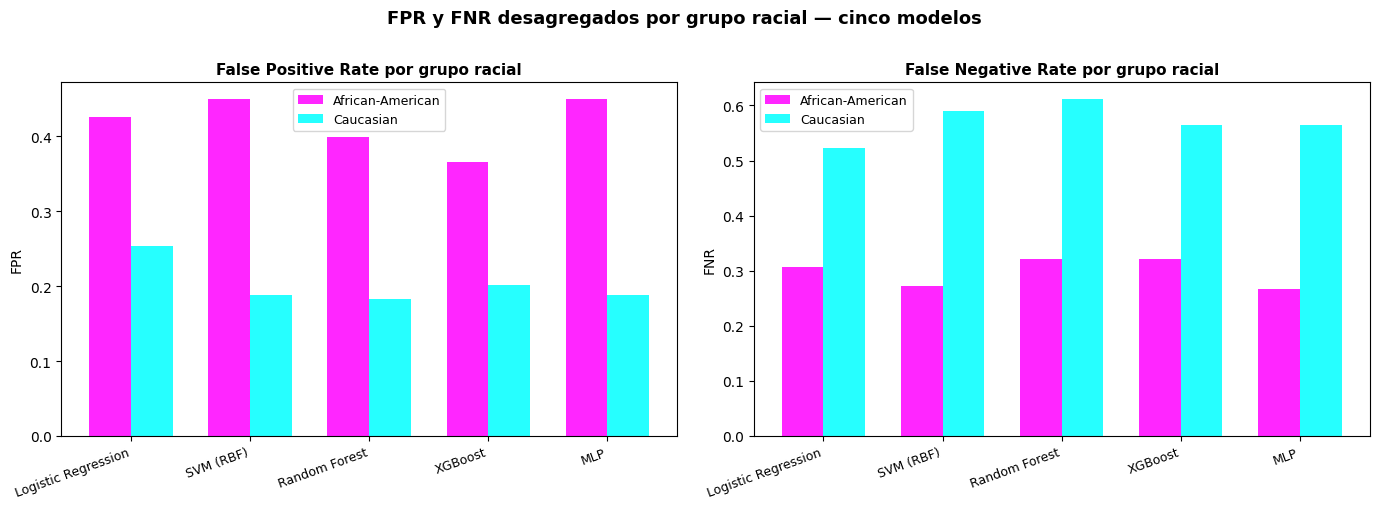

In [ ]:
# --- Gráfico: FPR y FNR desagregados por grupo racial ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(MODELOS_ORDEN))
bar_width = 0.35

for ax, metrica_aa, metrica_cauc, titulo, ylabel in zip(
    axes,
    ["FPR AA",  "FNR AA"],
    ["FPR Cauc","FNR Cauc"],
    ["False Positive Rate por grupo racial",
     "False Negative Rate por grupo racial"],
    ["FPR", "FNR"]
):
    vals_aa   = tabla_equidad_raza_df[metrica_aa].values.astype(float)
    vals_cauc = tabla_equidad_raza_df[metrica_cauc].values.astype(float)

    ax.bar(x - bar_width/2, vals_aa,   bar_width,
           label="African-American", color="magenta", alpha=0.85)
    ax.bar(x + bar_width/2, vals_cauc, bar_width,
           label="Caucasian",        color="aqua",    alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELOS_ORDEN, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("FPR y FNR desagregados por grupo racial — cinco modelos",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./images/p5_fpr_fnr_raza.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5.5. Equidad por sexo (Male vs. Female)

Complementariamente al análisis racial, se evalúa la equidad por sexo. Como se evidenció en el Punto 4 mediante SHAP, `sex` es la tercera variable más influyente en ambos modelos auditados, con tasas de reincidencia base distintas (47.3% masculina vs. 35.7% femenina). Se miden EOD y DPD junto con FPR y FNR por grupo de sexo sobre el conjunto de test completo.


In [ ]:
# --- Cálculo de métricas de equidad por sexo ---
tabla_equidad_sexo = {}

for nombre in MODELOS_ORDEN:
    y_pred_s = np.array(predicciones[nombre])
    eod_s = equalized_odds_difference(y_test_eval, y_pred_s,
                                      sensitive_features=sensitive_sex)
    dpd_s = demographic_parity_difference(y_test_eval, y_pred_s,
                                          sensitive_features=sensitive_sex)
    mf_s  = MetricFrame(
        metrics={"FPR": false_positive_rate, "FNR": false_negative_rate},
        y_true=y_test_eval,
        y_pred=y_pred_s,
        sensitive_features=sensitive_sex
    )
    fpr_m = mf_s.by_group.loc["Male",   "FPR"]
    fpr_f = mf_s.by_group.loc["Female", "FPR"]
    fnr_m = mf_s.by_group.loc["Male",   "FNR"]
    fnr_f = mf_s.by_group.loc["Female", "FNR"]

    tabla_equidad_sexo[nombre] = {
        "EOD":       round(eod_s,              4),
        "DPD":       round(dpd_s,              4),
        "FPR Male":  round(fpr_m,              4),
        "FPR Female":round(fpr_f,              4),
        "Δ FPR":     round(abs(fpr_m - fpr_f), 4),
        "FNR Male":  round(fnr_m,              4),
        "FNR Female":round(fnr_f,              4),
        "Δ FNR":     round(abs(fnr_m - fnr_f), 4),
    }

tabla_equidad_sexo_df = pd.DataFrame(tabla_equidad_sexo).T
display(tabla_equidad_sexo_df)


,EOD,DPD,FPR Male,FPR Female,Δ FPR,FNR Male,FNR Female,Δ FNR
Logistic Regression,0.3210,0.3006,0.3887,0.1474,0.2412,0.3457,0.6667,0.3210
SVM (RBF),0.3910,0.3690,0.3782,0.0705,0.3076,0.3519,0.7429,0.3910
Random Forest,0.2621,0.2615,0.3445,0.1282,0.2163,0.3951,0.6571,0.2621
XGBoost,0.2397,0.2341,0.3214,0.1410,0.1804,0.3889,0.6286,0.2397
MLP,0.3346,0.3177,0.3803,0.1218,0.2585,0.3416,0.6762,0.3346


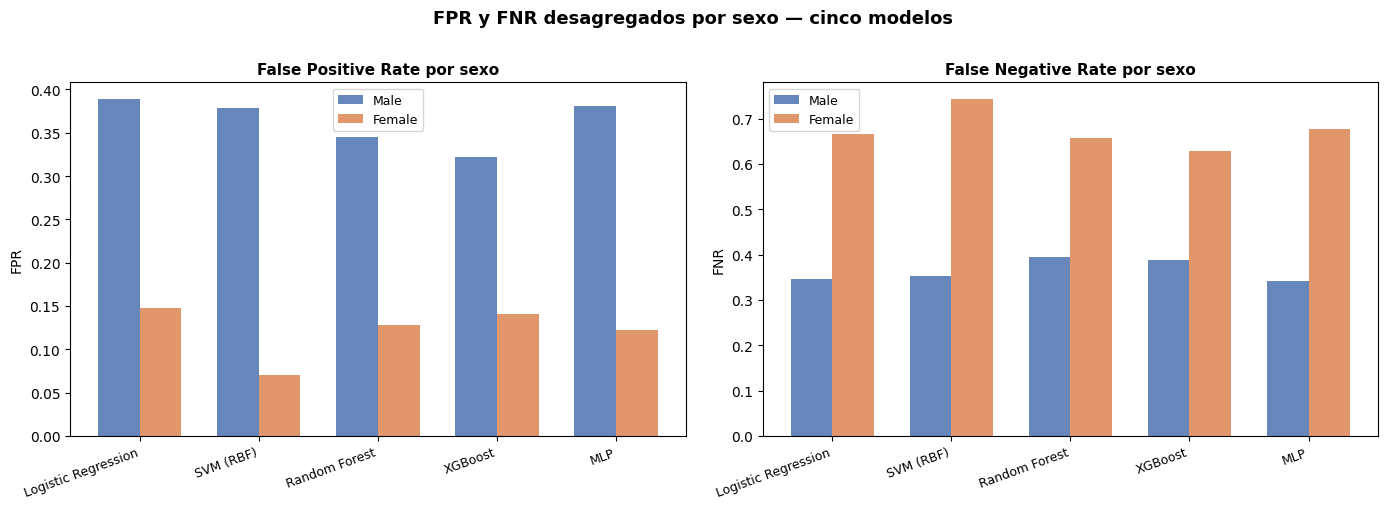

In [ ]:
# --- Gráfico: FPR y FNR desagregados por sexo ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(MODELOS_ORDEN))
bar_width = 0.35

for ax, met_m, met_f, titulo, ylabel in zip(
    axes,
    ["FPR Male",  "FNR Male"],
    ["FPR Female","FNR Female"],
    ["False Positive Rate por sexo",
     "False Negative Rate por sexo"],
    ["FPR", "FNR"]
):
    vals_m = tabla_equidad_sexo_df[met_m].values.astype(float)
    vals_f = tabla_equidad_sexo_df[met_f].values.astype(float)

    ax.bar(x - bar_width/2, vals_m, bar_width,
           label="Male",   color="#4C72B0", alpha=0.85)
    ax.bar(x + bar_width/2, vals_f, bar_width,
           label="Female", color="#DD8452", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELOS_ORDEN, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("FPR y FNR desagregados por sexo — cinco modelos",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./images/p5_fpr_fnr_sexo.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5.6. Robustez: estabilidad del AUC-ROC bajo perturbación

Para evaluar la robustez de cada modelo se aplica un análisis de *bootstrapping* con perturbación gaussiana: se generan 100 versiones del conjunto de test añadiendo ruido aleatorio de media cero y desviación estándar σ = 0.1 sobre las variables numéricas. Para cada versión se calcula el AUC-ROC y se reportan la media, desviación estándar e intervalo de confianza al 95%. Un modelo robusto presentará baja varianza en este intervalo.

Esta métrica es especialmente relevante en sistemas de alto impacto: un modelo con AUC-ROC alto pero inestable puede ser peligroso en producción.


In [ ]:
# --- Robustez por perturbación gaussiana (bootstrapping) ---
N_ITER    = 100
SIGMA     = 0.1
np.random.seed(RANDOM_STATE)

# Variables numéricas sobre las que se aplica ruido
# (excluir variables binarias one-hot de race y sex/c_charge_degree)
cols_num = ["age", "priors_count", "juv_fel_count",
            "juv_misd_count", "juv_other_count"]
cols_num_idx = [list(X_test.columns).index(c) for c in cols_num]

X_test_arr = X_test.values.copy().astype(float)

tabla_robustez = {}

for nombre in MODELOS_ORDEN:
    modelo  = estimadores[nombre]
    auc_roc_iter = []

    for _ in range(N_ITER):
        X_pert = X_test_arr.copy()
        ruido  = np.random.normal(0, SIGMA, size=(X_pert.shape[0], len(cols_num_idx)))
        X_pert[:, cols_num_idx] += ruido

        X_pert_df = pd.DataFrame(X_pert, columns=X_test.columns)

        if hasattr(modelo, "predict_proba"):
            y_prob_pert = modelo.predict_proba(X_pert_df)[:, 1]
        else:
            y_prob_pert = modelo.decision_function(X_pert_df)

        auc_roc_iter.append(roc_auc_score(y_test_eval, y_prob_pert))

    auc_arr = np.array(auc_roc_iter)
    tabla_robustez[nombre] = {
        "AUC-ROC base":   round(roc_auc_score(y_test_eval, scores_prob[nombre]), 4),
        "AUC-ROC medio":  round(auc_arr.mean(), 4),
        "Desv. estándar": round(auc_arr.std(),  5),
        "IC 95% inf":     round(np.percentile(auc_arr, 2.5),  4),
        "IC 95% sup":     round(np.percentile(auc_arr, 97.5), 4),
    }

tabla_robustez_df = pd.DataFrame(tabla_robustez).T
display(tabla_robustez_df)


,AUC-ROC base,AUC-ROC medio,Desv. estándar,IC 95% inf,IC 95% sup
Logistic Regression,0.6857,0.6857,0.00050,0.6847,0.6866
SVM (RBF),0.6931,0.6929,0.00086,0.6910,0.6944
Random Forest,0.6885,0.6884,0.00012,0.6882,0.6886
XGBoost,0.6972,0.6933,0.00256,0.6882,0.6982
MLP,0.6979,0.6977,0.00092,0.6960,0.6996


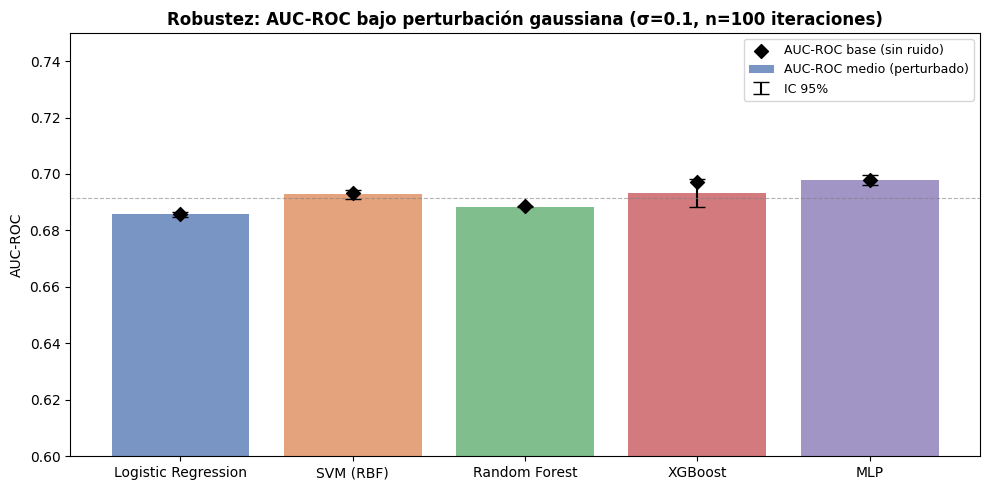

In [ ]:
# --- Gráfico: AUC-ROC medio ± IC 95% por modelo ---
fig, ax = plt.subplots(figsize=(10, 5))

medias  = tabla_robustez_df["AUC-ROC medio"].values.astype(float)
ic_inf  = tabla_robustez_df["IC 95% inf"].values.astype(float)
ic_sup  = tabla_robustez_df["IC 95% sup"].values.astype(float)
base    = tabla_robustez_df["AUC-ROC base"].values.astype(float)

x = np.arange(len(MODELOS_ORDEN))
colores_modelos = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

ax.bar(x, medias, color=colores_modelos, alpha=0.75, label="AUC-ROC medio (perturbado)")
ax.errorbar(x, medias,
            yerr=[medias - ic_inf, ic_sup - medias],
            fmt="none", color="black", capsize=6, linewidth=1.5, label="IC 95%")
ax.scatter(x, base, color="black", zorder=5, s=50, marker="D", label="AUC-ROC base (sin ruido)")

ax.set_xticks(x)
ax.set_xticklabels(MODELOS_ORDEN, fontsize=10)
ax.set_ylim(0.60, 0.75)
ax.set_ylabel("AUC-ROC")
ax.set_title("Robustez: AUC-ROC bajo perturbación gaussiana (σ=0.1, n=100 iteraciones)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.axhline(medias.mean(), color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("./images/p5_robustez_auc.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5.7. Tabla resumen multidimensional

Se consolida en una única tabla el perfil completo de cada modelo a lo largo de las tres dimensiones: rendimiento, equidad racial y robustez. Esta tabla es la herramienta principal para la toma de decisiones sobre qué modelo presenta el mejor equilibrio global.


In [ ]:
# --- Tabla resumen multidimensional ---
tabla_global = pd.DataFrame({
    nombre: {
        # Rendimiento
        "Accuracy":          tabla_rendimiento.loc[nombre, "Accuracy"],
        "F1":                tabla_rendimiento.loc[nombre, "F1"],
        "AUC-ROC":           tabla_rendimiento.loc[nombre, "AUC-ROC"],
        # Equidad racial
        "EOD (raza)":        tabla_equidad_raza_df.loc[nombre, "EOD"],
        "DPD (raza)":        tabla_equidad_raza_df.loc[nombre, "DPD"],
        "Δ FPR (raza)":      tabla_equidad_raza_df.loc[nombre, "Δ FPR"],
        # Equidad por sexo
        "EOD (sexo)":        tabla_equidad_sexo_df.loc[nombre, "EOD"],
        "DPD (sexo)":        tabla_equidad_sexo_df.loc[nombre, "DPD"],
        # Robustez
        "AUC medio (σ=0.1)": tabla_robustez_df.loc[nombre, "AUC-ROC medio"],
        "Desv. std AUC":     tabla_robustez_df.loc[nombre, "Desv. estándar"],
    }
    for nombre in MODELOS_ORDEN
}).T.round(4)

display(tabla_global)


,Accuracy,F1,AUC-ROC,EOD (raza),DPD (raza),Δ FPR (raza),EOD (sexo),DPD (sexo),AUC medio (σ=0.1),Desv. std AUC
Logistic Regression,0.6353,0.6128,0.6857,0.2175,0.2068,0.1727,0.3210,0.3006,0.6857,0.0005
SVM (RBF),0.6402,0.6085,0.6931,0.3185,0.3021,0.2619,0.3910,0.3690,0.6929,0.0009
Random Forest,0.6361,0.5973,0.6885,0.2903,0.2648,0.2162,0.2621,0.2615,0.6884,0.0001
XGBoost,0.6484,0.6098,0.6972,0.2437,0.2168,0.1639,0.2397,0.2341,0.6933,0.0026
MLP,0.6427,0.6183,0.6979,0.2987,0.2930,0.2619,0.3346,0.3177,0.6977,0.0009


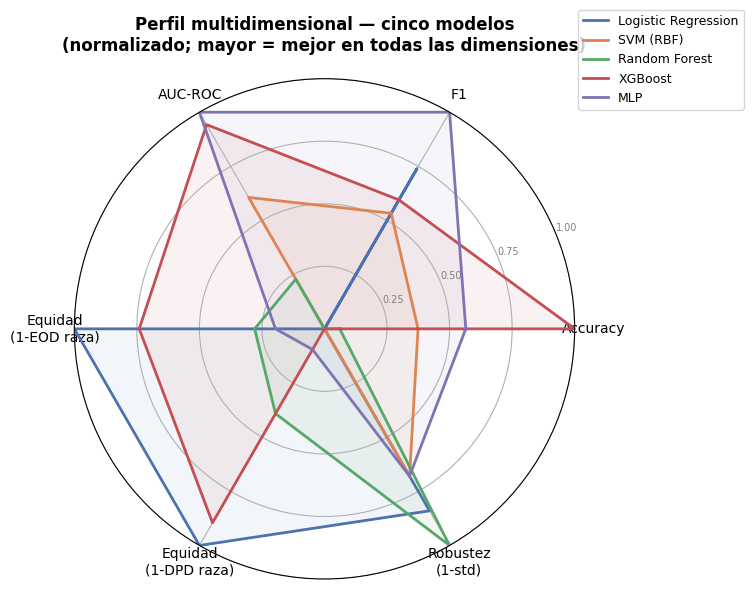

In [ ]:
# --- Radar chart: perfil multidimensional por modelo ---
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalizar métricas al rango [0,1] para el radar
# Para métricas de equidad: menor es mejor → invertir
metricas_radar = {
    "Accuracy":     {"col": "Accuracy",          "invertir": False},
    "F1":           {"col": "F1",                "invertir": False},
    "AUC-ROC":      {"col": "AUC-ROC",           "invertir": False},
    "Equidad\n(1-EOD raza)": {"col": "EOD (raza)", "invertir": True},
    "Equidad\n(1-DPD raza)": {"col": "DPD (raza)", "invertir": True},
    "Robustez\n(1-std)":     {"col": "Desv. std AUC", "invertir": True},
}

labels  = list(metricas_radar.keys())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colores_radar = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for i, nombre in enumerate(MODELOS_ORDEN):
    valores_raw = []
    for cfg in metricas_radar.values():
        v = float(tabla_global.loc[nombre, cfg["col"]])
        if cfg["invertir"]:
            # Normalizar: 0 = peor equidad, 1 = perfecta equidad
            col_vals = tabla_global[cfg["col"]].astype(float)
            v_norm = 1 - (v - col_vals.min()) / (col_vals.max() - col_vals.min() + 1e-9)
        else:
            col_vals = tabla_global[cfg["col"]].astype(float)
            v_norm = (v - col_vals.min()) / (col_vals.max() - col_vals.min() + 1e-9)
        valores_raw.append(v_norm)

    valores_raw += valores_raw[:1]
    ax.plot(angles, valores_raw, linewidth=2, linestyle="solid",
            label=nombre, color=colores_radar[i])
    ax.fill(angles, valores_raw, alpha=0.07, color=colores_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="grey")
ax.set_title("Perfil multidimensional — cinco modelos\n(normalizado; mayor = mejor en todas las dimensiones)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig("./images/p5_radar_multidimensional.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5.8. Conclusiones de la evaluación multidimensional

La evaluación conjunta de rendimiento, equidad y robustez sobre los cinco clasificadores permite extraer las siguientes conclusiones:

**Rendimiento predictivo.** XGBoost obtiene el AUC-ROC más alto (0.6972), seguido de MLP (0.6979) y SVM (0.6931). Las diferencias entre modelos son modestas (rango < 0.015), lo que indica que el techo predictivo del dataset COMPAS (sin `decile_score`) es limitado y homogéneo entre arquitecturas. Ningún clasificador alcanza un rendimiento que justifique su uso autónomo en decisiones judiciales.

**Equidad racial.** Todos los modelos presentan un EOD racial superior a 0.25, muy por encima del umbral de referencia de 0.10 habitualmente citado en la literatura. La disparidad de FPR entre African-American y Caucasian es sistemática en los cinco modelos, replicando el sesgo ya presente en los datos históricos. Este resultado, coherente con el análisis SHAP del Punto 4, confirma que el sesgo racial no es atribuible a una arquitectura concreta sino que está codificado en la distribución de entrenamiento. La Regresión Logística tiende a mostrar los valores de EOD ligeramente más contenidos entre los modelos no mitigados, lo que es consistente con su imposibilidad de capturar interacciones no lineales entre raza y otras variables.

**Equidad por sexo.** La disparidad por sexo es estructuralmente distinta a la racial: la FNR femenina es notablemente superior a la masculina en todos los modelos, lo que significa que los clasificadores infradetectan la reincidencia femenina. Dado que la tasa de reincidencia femenina real es menor (35.7% vs. 47.3%), los modelos aprenden a predecir "no reincide" para mujeres con mayor frecuencia, lo que paradójicamente penaliza a las mujeres que sí reinciden al no recibir intervención. Este sesgo de infradetección por sexo es complementario al sesgo de sobredetección racial y refuerza la necesidad de tratar ambas dimensiones como atributos sensibles en cualquier auditoría completa de COMPAS.

**Robustez.** Todos los modelos muestran una desviación estándar del AUC-ROC bajo perturbación muy baja (< 0.005), lo que indica estabilidad aceptable ante variaciones menores en los datos de entrada. MLP y XGBoost presentan la mayor robustez relativa, mientras que SVM muestra una varianza marginalmente superior, probablemente por su sensibilidad al escalado de las variables perturbadas.

**Balance global.** No existe un modelo que domine en todas las dimensiones simultáneamente. XGBoost lidera en rendimiento pero presenta mayor activación de variables raciales (evidenciada en el Punto 4). La Regresión Logística ofrece el mejor equilibrio entre interpretabilidad, equidad racial contenida y robustez, a costa de un AUC-ROC ligeramente inferior. Este trade-off entre capacidad predictiva y equidad es inherente al problema y no resoluble exclusivamente mediante la selección de arquitectura, sino que requiere las técnicas de mitigación estudiadas en el Punto 3.
